# Peak Counts Analysis for Weak Lensing Convergence Maps

This notebook analyzes peak counts in weak lensing convergence (κ) maps from the hydro_replace simulations.

## Overview
- **Data**: Ray-traced κ maps from DMO, Hydro, and Replace models
- **Source redshift**: z_s ≈ 1.0 (kappa20.dat)
- **Smoothing**: 2.5 arcmin Gaussian
- **Statistics**: Peak counts, minima counts, and PDF in S/N bins
- **Goal**: Compute response fraction F to quantify how much of the baryonic effect is captured

---

## Mathematical Framework

### 1. Data Structure

We have **500 pseudo-independent realizations** of convergence maps:
- 10 lens plane orientations (LP_00 to LP_09)  
- 50 random ray-tracing seeds per LP (run001 to run050)

Each realization produces a 1024×1024 κ map for three simulation types:
- **DMO** (D): Dark Matter Only
- **Hydro** (H): Full hydrodynamic simulation (IllustrisTNG)
- **Replace** (R): Hybrid where DMO halos are replaced with matched Hydro halos within α×R₂₀₀

### 2. Map Processing

#### Step 2.1: Gaussian Smoothing
Each raw κ map is convolved with a Gaussian kernel:

$$\kappa_{\rm smooth}(\mathbf{x}) = \kappa(\mathbf{x}) * G_\sigma(\mathbf{x})$$

where $G_\sigma$ is a 2D Gaussian with $\sigma = 2.5$ arcmin ≈ 8.53 pixels (for 5° FOV on 1024² grid).

#### Step 2.2: Signal-to-Noise Normalization
We normalize all maps to S/N units using the **DMO RMS** as the reference:

$$\sigma_\kappa^{\rm DMO} = \sqrt{\langle \kappa_{\rm smooth}^2 \rangle_{\rm DMO}} = \text{std}(\kappa_{\rm smooth}^{\rm DMO})$$

This is computed by averaging over all 500 DMO realizations:

$$\sigma_\kappa = \frac{1}{N_{\rm real}} \sum_{i=1}^{500} \text{std}(\kappa_{\rm smooth}^{(i)})$$

The S/N map is then:

$$\nu(\mathbf{x}) = \frac{\kappa_{\rm smooth}(\mathbf{x})}{\sigma_\kappa}$$

**Important**: We use the same $\sigma_\kappa$ (from DMO) to normalize DMO, Hydro, and Replace maps. This ensures we're measuring the same physical S/N threshold across all models.

### 3. Statistics Computed

For each S/N map, we compute three statistics:

#### 3.1 Peak Counts (Local Maxima)
A pixel is a **peak** if it is greater than all 8 neighbors:

$$\text{Peak at } (i,j) \iff \nu_{i,j} > \nu_{i+\delta_i, j+\delta_j} \quad \forall (\delta_i, \delta_j) \in \{-1,0,1\}^2 \setminus (0,0)$$

We bin peaks by their S/N value into bins $[\nu_a, \nu_b)$ and count:

$$N_{\rm peaks}^{(k)}(\nu_a, \nu_b) = \sum_{\mathbf{x} \in \text{peaks}} \mathbf{1}[\nu_a \leq \nu(\mathbf{x}) < \nu_b]$$

for realization $k$.

#### 3.2 Minima Counts (Local Minima)
Same as peaks but with reversed inequality:

$$\text{Minimum at } (i,j) \iff \nu_{i,j} < \nu_{i+\delta_i, j+\delta_j} \quad \forall (\delta_i, \delta_j)$$

#### 3.3 PDF (Pixel Histogram)
Simply histogram all pixel values:

$$N_{\rm PDF}^{(k)}(\nu_a, \nu_b) = \sum_{\mathbf{x}} \mathbf{1}[\nu_a \leq \nu(\mathbf{x}) < \nu_b]$$

### 4. Aggregation Across Realizations

For each statistic $S$ and S/N bin, we **sum counts across all 500 realizations**:

$$N_S^{\rm D} = \sum_{k=1}^{500} N_S^{(k), \rm D}$$

$$N_S^{\rm H} = \sum_{k=1}^{500} N_S^{(k), \rm H}$$

$$N_S^{\rm R} = \sum_{k=1}^{500} N_S^{(k), \rm R}$$

### 5. Baryonic Effect

The baryonic effect is the difference between Hydro and DMO:

$$\Delta N_S = N_S^{\rm H} - N_S^{\rm D}$$

- $\Delta N > 0$: Baryons **increase** the count in this bin
- $\Delta N < 0$: Baryons **decrease** the count in this bin

### 6. Response Fraction F

The **response fraction** measures what fraction of the baryonic effect is captured by the Replace model:

$$\boxed{F_S(\nu) = \frac{N_S^{\rm R}(\nu) - N_S^{\rm D}(\nu)}{N_S^{\rm H}(\nu) - N_S^{\rm D}(\nu)} = \frac{N_S^{\rm R} - N_S^{\rm D}}{\Delta N_S}}$$

#### Interpretation:
| Value | Meaning |
|-------|---------|
| $F = 0$ | Replace = DMO (no baryonic effect captured) |
| $F = 1$ | Replace = Hydro (full baryonic effect captured) |
| $0 < F < 1$ | Partial recovery of baryonic effect |
| $F > 1$ | **Over-correction**: Replace changes the field MORE than Hydro does |
| $F < 0$ | Replace goes in the wrong direction |

#### Why F > 1 can occur:
If $\Delta N < 0$ (Hydro has fewer counts than DMO) and Replace has even fewer counts, then:

$$F = \frac{(\text{negative, larger magnitude})}{(\text{negative, smaller magnitude})} > 1$$

This indicates the Replace procedure **over-corrects** — it modifies the field more aggressively than the true baryonic physics.

### 7. Weighted (Integrated) F

To get a single number summarizing F across all S/N bins, we compute:

$$F_{\rm weighted} = \frac{\sum_{\nu} (N_S^{\rm R}(\nu) - N_S^{\rm D}(\nu))}{\sum_{\nu} (N_S^{\rm H}(\nu) - N_S^{\rm D}(\nu))} = \frac{\sum_\nu (N_R - N_D)}{\sum_\nu \Delta N}$$

This weights each bin by the magnitude of its baryonic effect.

### 8. Bootstrap Error Estimation

Since our 500 realizations share cosmic variance (same underlying simulation), we use **bootstrap resampling** to estimate uncertainties:

1. Draw 500 realizations **with replacement** from the original 500
2. Compute $F$ for this bootstrap sample
3. Repeat 1000 times
4. Report mean and standard deviation of the bootstrap $F$ distribution

$$\sigma_F = \text{std}(F^{(1)}, F^{(2)}, \ldots, F^{(1000)})$$

This properly accounts for correlations between DMO, Hydro, and Replace (they share the same random field realizations).

---

## Replace Model Parameters

Each Replace model is defined by two parameters:

| Parameter | Description | Values |
|-----------|-------------|--------|
| $M_{\rm min}$ | Minimum halo mass to replace | $10^{12}, 10^{12.5}, 10^{13}, 10^{13.5}$ M☉/h |
| $\alpha$ | Radius factor (replace within $\alpha \times R_{200}$) | 0.5, 1.0, 3.0, 5.0 |

**Cumulative models**: All halos with $M > M_{\rm min}$ are replaced (no upper mass cut).

---

## Plot Guide

### Plot 1: DMO vs Hydro (3 rows × 2 columns)
- **Left column**: Bar charts showing $N^{\rm D}$ and $N^{\rm H}$ vs S/N
- **Right column**: Relative difference $(N^{\rm H} - N^{\rm D})/N^{\rm D}$ in percent
- **Rows**: Peaks, Minima, PDF

### Plot 2 & 3: F vs S/N (2×2 grids)
- **Each line**: Different Replace model
- **x-axis**: S/N bin center
- **y-axis**: $F = (N_R - N_D)/(N_H - N_D)$
- **Error bars**: Bootstrap standard deviation
- **Green band**: $F = 1 \pm 0.05$ (full recovery region)

### Plot 4: Weighted F Heatmaps (1×3)
- **Rows**: Mass threshold $M_{\rm min}$
- **Columns**: Radius factor $\alpha$
- **Color**: $F_{\rm weighted}$
- **Text**: $F \pm \sigma_F$

### Peak Type Analysis
Bins are grouped by physical interpretation:
| Type | S/N Range | Physical Origin |
|------|-----------|-----------------|
| Negative (voids) | $\nu < 0$ | Underdense regions |
| Low | $0 < \nu < 2$ | Moderate overdensities |
| Intermediate | $2 < \nu < 5$ | Groups, filaments |
| High (clusters) | $\nu > 5$ | Massive clusters |

In [1]:
# =============================================================================
# Imports and Setup
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from tqdm import tqdm
import warnings

# Plot settings
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 10

print("Imports loaded successfully")

Imports loaded successfully


In [9]:
# =============================================================================
# Configuration
# =============================================================================

# Data paths
RT_BASE = '/mnt/home/mlee1/ceph/hydro_replace_RT/L205n2500TNG'

# Grid and field of view
RT_GRID = 1024
FOV_DEG = 5.0  # 5 degree field of view

# Smoothing configuration
SMOOTHING_ARCMIN = 2.5  # 2 arcmin Gaussian smoothing
KAPPA_IDX = 20  # kappa23.dat - source redshift z_s ~ 1.0

# =============================================================================
# S/N bins for different statistics (1 bin per S/N unit)
# =============================================================================

# Peak counts (maxima): S/N from -2 to 10 (12 bins)
PEAK_SN_MIN, PEAK_SN_MAX = -5.0, 10.0
N_PEAK_BINS = int(PEAK_SN_MAX - PEAK_SN_MIN)  # 12 bins
PEAK_BINS = np.linspace(PEAK_SN_MIN, PEAK_SN_MAX, N_PEAK_BINS + 1)
PEAK_CENTERS = 0.5 * (PEAK_BINS[:-1] + PEAK_BINS[1:])

# Minima counts: S/N from -5 to 7 (12 bins)
MINIMA_SN_MIN, MINIMA_SN_MAX = -5.0, 10.0
N_MINIMA_BINS = int(MINIMA_SN_MAX - MINIMA_SN_MIN)  # 12 bins
MINIMA_BINS = np.linspace(MINIMA_SN_MIN, MINIMA_SN_MAX, N_MINIMA_BINS + 1)
MINIMA_CENTERS = 0.5 * (MINIMA_BINS[:-1] + MINIMA_BINS[1:])

# PDF of pixel values: S/N from -5 to 10 (15 bins)
PDF_SN_MIN, PDF_SN_MAX = -5.0, 10.0
N_PDF_BINS = int(PDF_SN_MAX - PDF_SN_MIN)  # 15 bins
PDF_BINS = np.linspace(PDF_SN_MIN, PDF_SN_MAX, N_PDF_BINS + 1)
PDF_CENTERS = 0.5 * (PDF_BINS[:-1] + PDF_BINS[1:])

# Legacy aliases for backward compatibility
N_SN_BINS = N_PEAK_BINS
SN_MIN, SN_MAX = PEAK_SN_MIN, PEAK_SN_MAX
SN_BINS = PEAK_BINS
SN_CENTERS = PEAK_CENTERS

# Number of lens planes and runs
N_RUNS = 50  # run001 through run050
N_LP = 10    # LP_00 through LP_09

# Smoothing scale in pixels
# 5 deg = 300 arcmin, so 1 arcmin = 1024/300 pixels = 3.41 pixels
PIXEL_SCALE_ARCMIN = FOV_DEG * 60.0 / RT_GRID  # arcmin per pixel
SIGMA_PIXELS = SMOOTHING_ARCMIN / PIXEL_SCALE_ARCMIN

print(f"Total realizations: {N_LP} LPs × {N_RUNS} runs = {N_LP * N_RUNS}")
print(f"\nStatistics bins:")
print(f"  Peaks (maxima): {N_PEAK_BINS} bins from {PEAK_SN_MIN}σ to {PEAK_SN_MAX}σ")
print(f"  Minima:         {N_MINIMA_BINS} bins from {MINIMA_SN_MIN}σ to {MINIMA_SN_MAX}σ")
print(f"  PDF:            {N_PDF_BINS} bins from {PDF_SN_MIN}σ to {PDF_SN_MAX}σ")
print(f"\nPixel scale: {PIXEL_SCALE_ARCMIN:.4f} arcmin/pixel")
print(f"Smoothing scale: {SMOOTHING_ARCMIN} arcmin = {SIGMA_PIXELS:.2f} pixels")

Total realizations: 10 LPs × 50 runs = 500

Statistics bins:
  Peaks (maxima): 15 bins from -5.0σ to 10.0σ
  Minima:         15 bins from -5.0σ to 10.0σ
  PDF:            15 bins from -5.0σ to 10.0σ

Pixel scale: 0.2930 arcmin/pixel
Smoothing scale: 2.5 arcmin = 8.53 pixels


In [10]:
# =============================================================================
# Models to Process
# =============================================================================

# Cumulative Replace models (Mu_inf = all masses above threshold)
CUMULATIVE_MODELS = [
    'hydro_replace_Ml_1.00e12_Mu_inf_R_0.5',
    'hydro_replace_Ml_1.00e12_Mu_inf_R_1.0',
    'hydro_replace_Ml_1.00e12_Mu_inf_R_3.0',
    'hydro_replace_Ml_1.00e12_Mu_inf_R_5.0',
    'hydro_replace_Ml_3.16e12_Mu_inf_R_0.5',
    'hydro_replace_Ml_3.16e12_Mu_inf_R_1.0',
    'hydro_replace_Ml_3.16e12_Mu_inf_R_3.0',
    'hydro_replace_Ml_3.16e12_Mu_inf_R_5.0',
    'hydro_replace_Ml_1.00e13_Mu_inf_R_0.5',
    'hydro_replace_Ml_1.00e13_Mu_inf_R_1.0',
    'hydro_replace_Ml_1.00e13_Mu_inf_R_3.0',
    'hydro_replace_Ml_1.00e13_Mu_inf_R_5.0',
    'hydro_replace_Ml_3.16e13_Mu_inf_R_0.5',
    'hydro_replace_Ml_3.16e13_Mu_inf_R_1.0',
    'hydro_replace_Ml_3.16e13_Mu_inf_R_3.0',
    'hydro_replace_Ml_3.16e13_Mu_inf_R_5.0',
]

# Mass thresholds and radii for grid organization
mass_thresholds_cum = ['1.00e12', '3.16e12', '1.00e13', '3.16e13']
radii_cum = ['0.5', '1.0', '3.0', '5.0']

# Labels for plotting
MASS_LABELS_LOG_CUM = [r'$M > 10^{12.0}$', r'$M > 10^{12.5}$', 
                       r'$M > 10^{13.0}$', r'$M > 10^{13.5}$']
RADIUS_LABELS_CUM = [r'$R < 0.5 R_{200}$', r'$R < 1.0 R_{200}$', 
                     r'$R < 3.0 R_{200}$', r'$R < 5.0 R_{200}$']

print(f"Number of models: {len(CUMULATIVE_MODELS)}")
print(f"Mass thresholds: {mass_thresholds_cum}")
print(f"Radius factors: {radii_cum}")

Number of models: 16
Mass thresholds: ['1.00e12', '3.16e12', '1.00e13', '3.16e13']
Radius factors: ['0.5', '1.0', '3.0', '5.0']


In [11]:
# =============================================================================
# Helper Functions
# =============================================================================

def load_kappa(fname, ng=1024):
    """Load single kappa map from lux binary format."""
    try:
        with open(fname, 'rb') as f:
            dummy = np.fromfile(f, dtype="int32", count=1)
            kappa = np.fromfile(f, dtype="float", count=ng*ng)
            dummy = np.fromfile(f, dtype="int32", count=1)
        kappa = kappa.reshape(ng, ng)
        if np.any(~np.isfinite(kappa)):
            return None
        return kappa
    except Exception:
        return None


def compute_all_statistics(kappa, sigma_pix, rms_norm, peak_bins, minima_bins, pdf_bins):
    """
    Compute peak counts, minima counts, and PDF from a kappa map.
    
    Parameters:
    -----------
    kappa : 2D array
        Raw convergence map
    sigma_pix : float
        Gaussian smoothing scale in pixels
    rms_norm : float
        RMS of DMO maps for S/N normalization
    peak_bins, minima_bins, pdf_bins : arrays
        Bin edges for each statistic
        
    Returns:
    --------
    peak_counts, minima_counts, pdf_counts : arrays
        Histogram counts for each statistic
    """
    # Apply Gaussian smoothing
    kappa_smooth = gaussian_filter(kappa, sigma=sigma_pix, mode='wrap')
    
    # Convert to S/N
    sn_map = kappa_smooth / rms_norm
    
    # Find local maxima and minima using neighbor comparisons
    comparisons_gt = []  # greater than neighbors (for peaks)
    comparisons_lt = []  # less than neighbors (for minima)
    
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0:
                continue
            shifted = np.roll(np.roll(sn_map, di, axis=0), dj, axis=1)
            comparisons_gt.append(sn_map > shifted)
            comparisons_lt.append(sn_map < shifted)
    
    # Peaks: greater than all 8 neighbors
    is_peak = np.all(comparisons_gt, axis=0)
    peak_values = sn_map[is_peak]
    peak_counts, _ = np.histogram(peak_values, bins=peak_bins)
    
    # Minima: less than all 8 neighbors
    is_minimum = np.all(comparisons_lt, axis=0)
    minima_values = sn_map[is_minimum]
    minima_counts, _ = np.histogram(minima_values, bins=minima_bins)
    
    # PDF: histogram of all pixel values
    pdf_counts, _ = np.histogram(sn_map.flatten(), bins=pdf_bins)

    return peak_counts, minima_counts, pdf_counts


def compute_peak_counts_sn(kappa, sigma_pix, rms_norm, sn_bins):
    """
    Compute peak counts on a smoothed kappa map in S/N bins.
    (Legacy function for backward compatibility)
    """
    peak_counts, _, _ = compute_all_statistics(kappa, sigma_pix, rms_norm,
                                                sn_bins, sn_bins, sn_bins)
    return peak_counts


def parse_model_name(model):
    """Extract mass lower bound and radius from model name."""
    parts = model.split('_')
    ml = None
    r = None
    for i, p in enumerate(parts):
        if p == 'Ml':
            ml = parts[i+1]
        elif p == 'R':
            r = parts[i+1]
    return ml, r

print("Helper functions defined")

Helper functions defined


## Step 1: Compute RMS from DMO Maps

First we compute the RMS of the smoothed DMO kappa maps. This will be used to normalize all maps to S/N units.

In [12]:
# =============================================================================
# Compute RMS from DMO maps
# =============================================================================

print("Computing RMS of smoothed DMO kappa maps...")

rms_per_map = np.zeros((N_LP, N_RUNS))

for lp_idx in tqdm(range(N_LP), desc="Computing DMO RMS"):
    for run_idx in range(N_RUNS):
        run_id = run_idx + 1
        path = f"{RT_BASE}/dmo/LP_{lp_idx:02d}/run{run_id:03d}/kappa{KAPPA_IDX:02d}.dat"
        
        kappa = load_kappa(path, ng=RT_GRID)
        if kappa is not None:
            kappa_smooth = gaussian_filter(kappa, sigma=SIGMA_PIXELS, mode='wrap')
            rms_per_map[lp_idx, run_idx] = np.std(kappa_smooth)
        else:
            rms_per_map[lp_idx, run_idx] = np.nan

RMS_MEAN = np.nanmean(rms_per_map)
RMS_STD = np.nanstd(rms_per_map)

print(f"\nDMO RMS statistics:")
print(f"  Mean RMS (σ_κ): {RMS_MEAN:.5f}")
print(f"  Std of RMS: {RMS_STD:.5f}")
print(f"  Valid maps: {np.sum(~np.isnan(rms_per_map))} / {N_LP * N_RUNS}")

Computing RMS of smoothed DMO kappa maps...


Computing DMO RMS: 100%|██████████| 10/10 [01:52<00:00, 11.24s/it]


DMO RMS statistics:
  Mean RMS (σ_κ): 0.00823
  Std of RMS: 0.00062
  Valid maps: 500 / 500


## Step 2: Load Peak Counts for All Models

Load peak counts for DMO, Hydro, and all Replace models in S/N bins.

In [13]:
# =============================================================================
# Load all statistics for DMO and Hydro
# =============================================================================

print("Loading statistics (peaks, minima, PDF) for DMO and Hydro...")

# Storage for all statistics
peak_counts_sn = {}
minima_counts_sn = {}
pdf_counts_sn = {}

for base_model in ['dmo', 'hydro']:
    print(f"  Processing {base_model}...")
    peak_arr = np.zeros((N_LP, N_RUNS, N_PEAK_BINS))
    minima_arr = np.zeros((N_LP, N_RUNS, N_MINIMA_BINS))
    pdf_arr = np.zeros((N_LP, N_RUNS, N_PDF_BINS))
    n_loaded = 0
    n_failed = 0
    
    for lp_idx in range(N_LP):
        for run_idx in range(N_RUNS):
            run_id = run_idx + 1
            path = f"{RT_BASE}/{base_model}/LP_{lp_idx:02d}/run{run_id:03d}/kappa{KAPPA_IDX:02d}.dat"
            
            kappa = load_kappa(path, ng=RT_GRID)
            if kappa is not None:
                peaks, minima, pdf = compute_all_statistics(
                    kappa, SIGMA_PIXELS, RMS_MEAN, PEAK_BINS, MINIMA_BINS, PDF_BINS
                )
                peak_arr[lp_idx, run_idx, :] = peaks
                minima_arr[lp_idx, run_idx, :] = minima
                pdf_arr[lp_idx, run_idx, :] = pdf
                n_loaded += 1
            else:
                n_failed += 1
    
    peak_counts_sn[base_model] = peak_arr
    minima_counts_sn[base_model] = minima_arr
    pdf_counts_sn[base_model] = pdf_arr
    print(f"    Loaded {n_loaded}, failed {n_failed}")

Loading statistics (peaks, minima, PDF) for DMO and Hydro...
  Processing dmo...


    Loaded 500, failed 0
  Processing hydro...
    Loaded 500, failed 0


In [14]:
# =============================================================================
# Load all statistics for Replace models
# =============================================================================

print("Loading statistics (peaks, minima, PDF) for Replace models...")

for model in tqdm(CUMULATIVE_MODELS, desc="Models"):
    peak_arr = np.zeros((N_LP, N_RUNS, N_PEAK_BINS))
    minima_arr = np.zeros((N_LP, N_RUNS, N_MINIMA_BINS))
    pdf_arr = np.zeros((N_LP, N_RUNS, N_PDF_BINS))
    n_loaded = 0
    n_failed = 0
    
    for lp_idx in range(N_LP):
        for run_idx in range(N_RUNS):
            run_id = run_idx + 1
            path = f"{RT_BASE}/{model}/LP_{lp_idx:02d}/run{run_id:03d}/kappa{KAPPA_IDX:02d}.dat"
            
            kappa = load_kappa(path, ng=RT_GRID)
            if kappa is not None:
                peaks, minima, pdf = compute_all_statistics(
                    kappa, SIGMA_PIXELS, RMS_MEAN, PEAK_BINS, MINIMA_BINS, PDF_BINS
                )
                peak_arr[lp_idx, run_idx, :] = peaks
                minima_arr[lp_idx, run_idx, :] = minima
                pdf_arr[lp_idx, run_idx, :] = pdf
                n_loaded += 1
            else:
                n_failed += 1
    
    peak_counts_sn[model] = peak_arr
    minima_counts_sn[model] = minima_arr
    pdf_counts_sn[model] = pdf_arr
    
print(f"\\nTotal models loaded: {len(peak_counts_sn)}")
print(f"Statistics computed: peaks, minima, PDF")

Loading statistics (peaks, minima, PDF) for Replace models...


Models: 100%|██████████| 16/16 [39:33<00:00, 148.37s/it]

\nTotal models loaded: 18
Statistics computed: peaks, minima, PDF


## Step 3: Compute Response Fraction F

Compute F = (N_R - N_D) / (N_H - N_D) for each Replace model and S/N bin.

In [15]:
# =============================================================================
# Compute Response Fraction F for All Statistics
# =============================================================================

def get_total_counts(data_dict, model_name):
    """Sum counts across all independent realizations (LPs x runs)."""
    data = data_dict[model_name]  # shape: (N_LP, N_RUNS, N_BINS)
    total = np.sum(data, axis=(0, 1))  # shape: (N_BINS,)
    return total

# For backward compatibility
def get_total_counts_sn(model_name):
    return get_total_counts(peak_counts_sn, model_name)

# Number of realizations
n_realizations = N_LP * N_RUNS

# =============================================================================
# PEAKS: DMO and Hydro baselines
# =============================================================================
N_D_peaks = get_total_counts(peak_counts_sn, 'dmo')
N_H_peaks = get_total_counts(peak_counts_sn, 'hydro')
Delta_N_peaks = N_H_peaks - N_D_peaks

# Legacy aliases
N_D, N_H, Delta_N = N_D_peaks, N_H_peaks, Delta_N_peaks
Delta_N_rel = Delta_N / N_D

print("PEAK COUNTS (maxima):")
print(f"  S/N range: [{PEAK_SN_MIN}, {PEAK_SN_MAX}]")
print(f"  DMO total: {np.sum(N_D_peaks):.0f}")
print(f"  Hydro total: {np.sum(N_H_peaks):.0f}")
print(f"  Baryonic change: {np.sum(Delta_N_peaks):.0f} ({100*np.sum(Delta_N_peaks)/np.sum(N_D_peaks):.2f}%)")

# =============================================================================
# MINIMA: DMO and Hydro baselines
# =============================================================================
N_D_minima = get_total_counts(minima_counts_sn, 'dmo')
N_H_minima = get_total_counts(minima_counts_sn, 'hydro')
Delta_N_minima = N_H_minima - N_D_minima

print(f"\nMINIMA COUNTS:")
print(f"  S/N range: [{MINIMA_SN_MIN}, {MINIMA_SN_MAX}]")
print(f"  DMO total: {np.sum(N_D_minima):.0f}")
print(f"  Hydro total: {np.sum(N_H_minima):.0f}")
print(f"  Baryonic change: {np.sum(Delta_N_minima):.0f} ({100*np.sum(Delta_N_minima)/np.sum(N_D_minima):.2f}%)")

# =============================================================================
# PDF: DMO and Hydro baselines
# =============================================================================
N_D_pdf = get_total_counts(pdf_counts_sn, 'dmo')
N_H_pdf = get_total_counts(pdf_counts_sn, 'hydro')
Delta_N_pdf = N_H_pdf - N_D_pdf

print(f"\nPDF (pixel histogram):")
print(f"  S/N range: [{PDF_SN_MIN}, {PDF_SN_MAX}]")
print(f"  DMO total: {np.sum(N_D_pdf):.0f}")
print(f"  Hydro total: {np.sum(N_H_pdf):.0f}")
print(f"  Baryonic change: {np.sum(Delta_N_pdf):.0f} ({100*np.sum(Delta_N_pdf)/np.sum(N_D_pdf):.2f}%)")

PEAK COUNTS (maxima):
  S/N range: [-5.0, 10.0]
  DMO total: 227906
  Hydro total: 224122
  Baryonic change: -3784 (-1.66%)

MINIMA COUNTS:
  S/N range: [-5.0, 10.0]
  DMO total: 209230
  Hydro total: 205451
  Baryonic change: -3779 (-1.81%)

PDF (pixel histogram):
  S/N range: [-5.0, 10.0]
  DMO total: 524252990
  Hydro total: 524248546
  Baryonic change: -4444 (-0.00%)


/tmp/ipykernel_2115398/1854944500.py:27: RuntimeWarning: invalid value encountered in divide
  Delta_N_rel = Delta_N / N_D


In [16]:
# =============================================================================
# Compute F for each Replace model (all three statistics)
# =============================================================================

F_peaks_sn = {}    # {model: F} for each peak S/N bin
F_minima_sn = {}   # {model: F} for each minima S/N bin
F_pdf_sn = {}      # {model: F} for each PDF S/N bin

for model in CUMULATIVE_MODELS:
    # PEAKS
    N_R_peaks = get_total_counts(peak_counts_sn, model)
    with np.errstate(divide='ignore', invalid='ignore'):
        F_p = (N_R_peaks - N_D_peaks) / Delta_N_peaks
        significant = np.abs(Delta_N_peaks) > 100
        F_p[~significant] = np.nan
    F_peaks_sn[model] = F_p
    
    # MINIMA
    N_R_minima = get_total_counts(minima_counts_sn, model)
    with np.errstate(divide='ignore', invalid='ignore'):
        F_m = (N_R_minima - N_D_minima) / Delta_N_minima
        significant = np.abs(Delta_N_minima) > 100
        F_m[~significant] = np.nan
    F_minima_sn[model] = F_m
    
    # PDF
    N_R_pdf = get_total_counts(pdf_counts_sn, model)
    with np.errstate(divide='ignore', invalid='ignore'):
        F_pdf = (N_R_pdf - N_D_pdf) / Delta_N_pdf
        # PDF has many more counts, use relative threshold
        significant = np.abs(Delta_N_pdf) > 1000
        F_pdf[~significant] = np.nan
    F_pdf_sn[model] = F_pdf

print(f"Computed F for {len(F_peaks_sn)} models x 3 statistics")

Computed F for 16 models x 3 statistics


## Error Analysis: Bootstrap Resampling

The correct approach for error propagation is to use **bootstrap resampling** over realizations, not Poisson errors on totals. This is because:

1. **Shared cosmic variance**: All models (DMO, Hydro, Replace) use the same underlying simulation, so their counts are correlated
2. **Pseudo-independence**: The 500 realizations (10 LPs × 50 runs) sample different lines of sight but share large-scale structure
3. **Ratio statistics**: F = (N_R - N_D)/(N_H - N_D) requires proper error propagation through the ratio

**Bootstrap approach**: Resample the 500 realizations with replacement, compute F for each bootstrap sample, and use the standard deviation as the uncertainty.

In [42]:
# =============================================================================
# Bootstrap Error Estimation for F
# =============================================================================

def bootstrap_F(data_R, data_D, data_H, n_bootstrap=1000, min_rel_effect=0.01):
    """
    Compute F and its uncertainty via bootstrap resampling over realizations.
    
    Parameters:
    -----------
    data_R, data_D, data_H : arrays of shape (N_LP, N_RUNS, N_BINS)
        Count data for Replace, DMO, and Hydro models
    n_bootstrap : int
        Number of bootstrap samples
    min_rel_effect : float
        Minimum |ΔN/N_D| to consider bin significant (default 1%)
        
    Returns:
    --------
    F_mean : array (N_BINS,)
        Mean F across bootstrap samples
    F_std : array (N_BINS,)
        Standard deviation of F (uncertainty)
    F_samples : array (n_bootstrap, N_BINS)
        All bootstrap F values
    """
    n_lp, n_runs, n_bins = data_R.shape
    n_realizations = n_lp * n_runs
    
    # Reshape to (n_realizations, n_bins)
    R_flat = data_R.reshape(n_realizations, n_bins)
    D_flat = data_D.reshape(n_realizations, n_bins)
    H_flat = data_H.reshape(n_realizations, n_bins)
    
    # Bootstrap samples
    rng = np.random.default_rng(42)
    F_samples = np.zeros((n_bootstrap, n_bins))
    
    for i in range(n_bootstrap):
        # Resample realizations with replacement
        idx = rng.choice(n_realizations, size=n_realizations, replace=True)
        
        # Sum counts for this bootstrap sample
        N_R = np.sum(R_flat[idx], axis=0)
        N_D = np.sum(D_flat[idx], axis=0)
        N_H = np.sum(H_flat[idx], axis=0)
        
        Delta_N = N_H - N_D
        
        with np.errstate(divide='ignore', invalid='ignore'):
            F = (N_R - N_D) / Delta_N
            # Mask bins with <1% relative baryonic effect
            rel_effect = np.abs(Delta_N) / (N_D + 1)  # +1 to avoid div by zero
            F[rel_effect < min_rel_effect] = np.nan
        
        F_samples[i] = F
    
    # Compute statistics
    F_mean = np.nanmean(F_samples, axis=0)
    F_std = np.nanstd(F_samples, axis=0)
    
    return F_mean, F_std, F_samples


# Compare Poisson vs Bootstrap errors for DMO baseline
print("Comparing error estimation methods for peak counts:")
print("=" * 70)

# Total counts (current method)
N_D_total = np.sum(peak_counts_sn['dmo'], axis=(0, 1))
N_H_total = np.sum(peak_counts_sn['hydro'], axis=(0, 1))

# Poisson errors (sqrt(N))
err_poisson_D = np.sqrt(N_D_total)
err_poisson_H = np.sqrt(N_H_total)

# Sample variance across realizations
# Mean counts per realization
mean_per_real_D = np.mean(peak_counts_sn['dmo'].reshape(-1, N_PEAK_BINS), axis=0)
std_per_real_D = np.std(peak_counts_sn['dmo'].reshape(-1, N_PEAK_BINS), axis=0)
sem_D = std_per_real_D / np.sqrt(n_realizations)  # Standard error of total

mean_per_real_H = np.mean(peak_counts_sn['hydro'].reshape(-1, N_PEAK_BINS), axis=0)
std_per_real_H = np.std(peak_counts_sn['hydro'].reshape(-1, N_PEAK_BINS), axis=0)
sem_H = std_per_real_H / np.sqrt(n_realizations)

# Scale SEM to total (multiply by n_realizations since total = n * mean)
err_sample_D = std_per_real_D * np.sqrt(n_realizations)  # σ_total = σ_single * sqrt(N)
err_sample_H = std_per_real_H * np.sqrt(n_realizations)

print(f"\nPeak counts error comparison (selected S/N bins):")
print(f"{'S/N':<8} {'N_D':<10} {'Poisson σ':<12} {'Sample σ':<12} {'Ratio':<8}")
print("-" * 55)
for i, sn in enumerate(PEAK_CENTERS):
    if sn in [-2, 0, 2, 4, 6]:
        ratio = err_sample_D[i] / err_poisson_D[i] if err_poisson_D[i] > 0 else np.nan
        print(f"{sn:<8.1f} {N_D_total[i]:<10.0f} {err_poisson_D[i]:<12.1f} {err_sample_D[i]:<12.1f} {ratio:<8.2f}")

print("\n→ If Ratio > 1: Sample variance exceeds Poisson (cosmic/sample variance dominates)")
print("→ If Ratio ≈ 1: Poisson noise dominates (independent counts)")
print("→ If Ratio < 1: Unlikely, would indicate sub-Poisson correlations")

Comparing error estimation methods for peak counts:

Peak counts error comparison (selected S/N bins):
S/N      N_D        Poisson σ    Sample σ     Ratio   
-------------------------------------------------------

→ If Ratio > 1: Sample variance exceeds Poisson (cosmic/sample variance dominates)
→ If Ratio ≈ 1: Poisson noise dominates (independent counts)
→ If Ratio < 1: Unlikely, would indicate sub-Poisson correlations


In [43]:
# =============================================================================
# Compute Bootstrap Errors for F (all Replace models, all statistics)
# =============================================================================

print("Computing bootstrap errors for F (peaks, minima, PDF)...")
print("This may take a few minutes...")

# Storage for F with errors for all statistics
F_peaks_bootstrap = {}    # {model: (F_mean, F_std)}
F_minima_bootstrap = {}
F_pdf_bootstrap = {}

# DMO and Hydro data (needed for all comparisons)
data_D_peaks = peak_counts_sn['dmo']
data_H_peaks = peak_counts_sn['hydro']
data_D_minima = minima_counts_sn['dmo']
data_H_minima = minima_counts_sn['hydro']
data_D_pdf = pdf_counts_sn['dmo']
data_H_pdf = pdf_counts_sn['hydro']

for model in tqdm(CUMULATIVE_MODELS, desc="Bootstrap (all stats)"):
    # Peaks
    data_R = peak_counts_sn[model]
    F_mean, F_std, _ = bootstrap_F(data_R, data_D_peaks, data_H_peaks, n_bootstrap=1000)
    F_peaks_bootstrap[model] = (F_mean, F_std)
    
    # Minima
    data_R = minima_counts_sn[model]
    F_mean, F_std, _ = bootstrap_F(data_R, data_D_minima, data_H_minima, n_bootstrap=1000)
    F_minima_bootstrap[model] = (F_mean, F_std)
    
    # PDF
    data_R = pdf_counts_sn[model]
    F_mean, F_std, _ = bootstrap_F(data_R, data_D_pdf, data_H_pdf, n_bootstrap=1000)
    F_pdf_bootstrap[model] = (F_mean, F_std)

print(f"\nBootstrap errors computed for {len(F_peaks_bootstrap)} models × 3 statistics")

# Build grids with errors for all statistics
F_grid_peaks_mean = np.full((len(mass_thresholds_cum), len(radii_cum), N_PEAK_BINS), np.nan)
F_grid_peaks_std = np.full((len(mass_thresholds_cum), len(radii_cum), N_PEAK_BINS), np.nan)
F_grid_minima_mean = np.full((len(mass_thresholds_cum), len(radii_cum), N_MINIMA_BINS), np.nan)
F_grid_minima_std = np.full((len(mass_thresholds_cum), len(radii_cum), N_MINIMA_BINS), np.nan)
F_grid_pdf_mean = np.full((len(mass_thresholds_cum), len(radii_cum), N_PDF_BINS), np.nan)
F_grid_pdf_std = np.full((len(mass_thresholds_cum), len(radii_cum), N_PDF_BINS), np.nan)

for model in CUMULATIVE_MODELS:
    ml, r = parse_model_name(model)
    if ml in mass_thresholds_cum and r in radii_cum:
        m_idx = mass_thresholds_cum.index(ml)
        r_idx = radii_cum.index(r)
        
        F_grid_peaks_mean[m_idx, r_idx, :] = F_peaks_bootstrap[model][0]
        F_grid_peaks_std[m_idx, r_idx, :] = F_peaks_bootstrap[model][1]
        F_grid_minima_mean[m_idx, r_idx, :] = F_minima_bootstrap[model][0]
        F_grid_minima_std[m_idx, r_idx, :] = F_minima_bootstrap[model][1]
        F_grid_pdf_mean[m_idx, r_idx, :] = F_pdf_bootstrap[model][0]
        F_grid_pdf_std[m_idx, r_idx, :] = F_pdf_bootstrap[model][1]

print("F grids with errors built successfully")

Computing bootstrap errors for F (peaks, minima, PDF)...
This may take a few minutes...


Bootstrap (all stats):   0%|          | 0/16 [00:00<?, ?it/s]/tmp/ipykernel_2115398/4067650711.py:59: RuntimeWarning: Mean of empty slice
  F_mean = np.nanmean(F_samples, axis=0)
/mnt/home/mlee1/venvs/hydro_replace/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
Bootstrap (all stats): 100%|██████████| 16/16 [00:04<00:00,  3.44it/s]


Bootstrap errors computed for 16 models × 3 statistics
F grids with errors built successfully


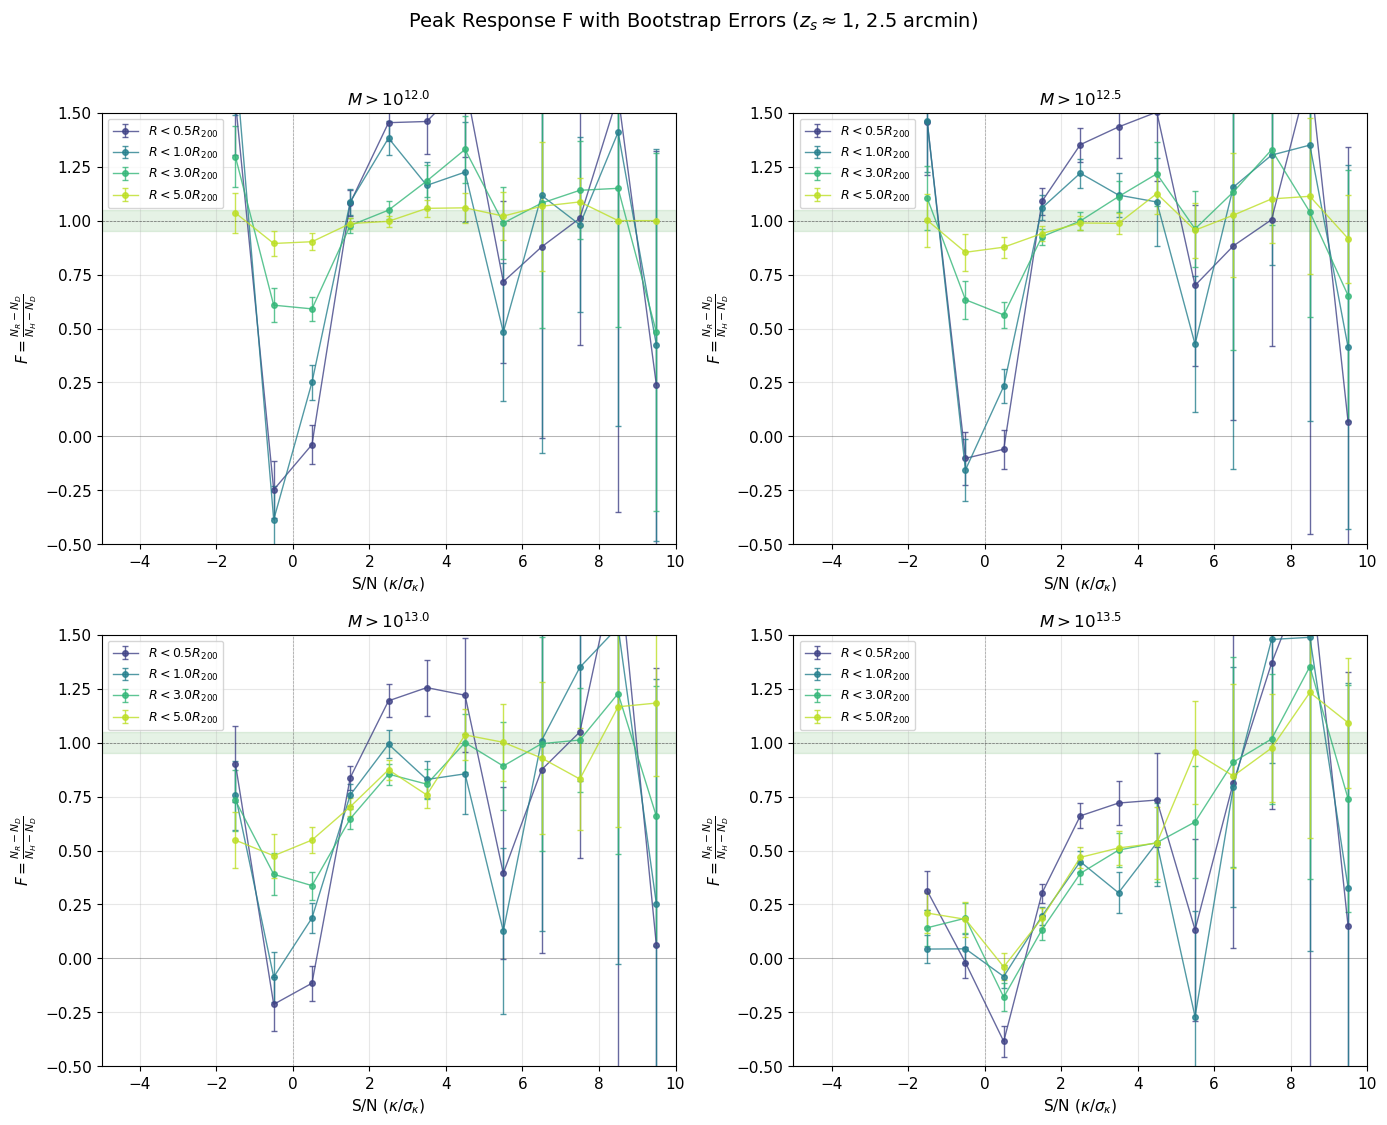


Typical bootstrap errors on F:
--------------------------------------------------
hydro_replace_Ml_1.00e12_Mu_inf_R_5.0:
  Mean σ_F = 0.073
  Max σ_F = 0.299
hydro_replace_Ml_1.00e13_Mu_inf_R_5.0:
  Mean σ_F = 0.185
  Max σ_F = 0.556


In [44]:
# =============================================================================
# Plot: F vs S/N with Bootstrap Error Bars
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

colors_radius = plt.cm.viridis(np.linspace(0.2, 0.9, len(radii_cum)))

for m_idx, (mass_thr, mass_label) in enumerate(zip(mass_thresholds_cum, MASS_LABELS_LOG_CUM)):
    ax = axes[m_idx]
    
    for r_idx, (r, r_label) in enumerate(zip(radii_cum, RADIUS_LABELS_CUM)):
        model = f'hydro_replace_Ml_{mass_thr}_Mu_inf_R_{r}'
        F_mean, F_std = F_peaks_bootstrap[model]
        
        # Only plot where we have valid data
        valid = np.isfinite(F_mean) & np.isfinite(F_std)
        if np.any(valid):
            ax.errorbar(PEAK_CENTERS[valid], F_mean[valid], yerr=F_std[valid],
                       marker='o', markersize=4, linestyle='-', linewidth=1,
                       color=colors_radius[r_idx], label=r_label, alpha=0.8,
                       capsize=2, capthick=1)
    
    ax.axhline(1, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.axvline(0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)
    ax.fill_between([PEAK_SN_MIN, PEAK_SN_MAX], 0.95, 1.05, color='green', alpha=0.1)
    ax.set_xlabel(r'S/N ($\kappa / \sigma_\kappa$)', fontsize=11)
    ax.set_ylabel(r'$F = \frac{N_R - N_D}{N_H - N_D}$', fontsize=11)
    ax.set_title(mass_label, fontsize=12)
    ax.set_xlim(PEAK_SN_MIN, PEAK_SN_MAX)
    ax.set_ylim(-0.5, 1.5)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Peak Response F with Bootstrap Errors ($z_s \\approx 1$, {SMOOTHING_ARCMIN} arcmin)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print summary of error magnitudes
print("\nTypical bootstrap errors on F:")
print("-" * 50)
for model in ['hydro_replace_Ml_1.00e12_Mu_inf_R_5.0', 
              'hydro_replace_Ml_1.00e13_Mu_inf_R_5.0']:
    F_mean, F_std = F_peaks_bootstrap[model]
    valid = np.isfinite(F_std)
    print(f"{model}:")
    print(f"  Mean σ_F = {np.nanmean(F_std):.3f}")
    print(f"  Max σ_F = {np.nanmax(F_std[valid]):.3f}")

Computing weighted F with bootstrap errors...


Weighted F: 100%|██████████| 16/16 [00:01<00:00,  9.35it/s]


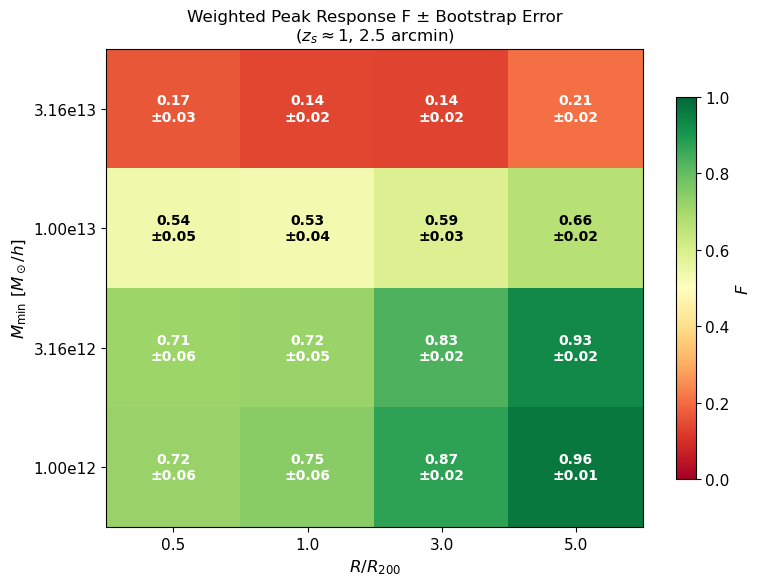


Weighted F with Bootstrap Errors:
Mass threshold       R=0.5          R=1.0          R=3.0          R=5.0         
----------------------------------------------------------------------
M > 1.00e12      0.72±0.06    
M > 1.00e12      0.72±0.06     0.75±0.06    
M > 1.00e12      0.72±0.06     0.75±0.06     0.87±0.02    
M > 1.00e12      0.72±0.06     0.75±0.06     0.87±0.02     0.96±0.01    
M > 3.16e12      0.71±0.06    
M > 3.16e12      0.71±0.06     0.72±0.05    
M > 3.16e12      0.71±0.06     0.72±0.05     0.83±0.02    
M > 3.16e12      0.71±0.06     0.72±0.05     0.83±0.02     0.93±0.02    
M > 1.00e13      0.54±0.05    
M > 1.00e13      0.54±0.05     0.53±0.04    
M > 1.00e13      0.54±0.05     0.53±0.04     0.59±0.03    
M > 1.00e13      0.54±0.05     0.53±0.04     0.59±0.03     0.66±0.02    
M > 3.16e13      0.17±0.03    
M > 3.16e13      0.17±0.03     0.14±0.02    
M > 3.16e13      0.17±0.03     0.14±0.02     0.14±0.02    
M > 3.16e13      0.17±0.03     0.14±0.02     0.14±0.02

In [ ]:
# =============================================================================
# Weighted F with Bootstrap Errors
# =============================================================================

def bootstrap_weighted_F(data_R, data_D, data_H, n_bootstrap=1000, min_rel_effect=0.01):
    """
    Compute weighted total F and uncertainty via bootstrap.
    
    F_total = sum(N_R - N_D) / sum(N_H - N_D) over bins with >1% relative effect
    """
    n_lp, n_runs, n_bins = data_R.shape
    n_realizations = n_lp * n_runs
    
    R_flat = data_R.reshape(n_realizations, n_bins)
    D_flat = data_D.reshape(n_realizations, n_bins)
    H_flat = data_H.reshape(n_realizations, n_bins)
    
    rng = np.random.default_rng(42)
    F_samples = np.zeros(n_bootstrap)
    
    for i in range(n_bootstrap):
        idx = rng.choice(n_realizations, size=n_realizations, replace=True)
        
        N_R = np.sum(R_flat[idx], axis=0)
        N_D = np.sum(D_flat[idx], axis=0)
        N_H = np.sum(H_flat[idx], axis=0)
        
        Delta_N = N_H - N_D
        # Require >1% relative baryonic effect
        rel_effect = np.abs(Delta_N) / (N_D + 1)  # +1 to avoid div by zero
        valid = rel_effect > min_rel_effect
        
        if np.sum(valid) > 0:
            F_samples[i] = np.sum((N_R - N_D)[valid]) / np.sum(Delta_N[valid])
        else:
            F_samples[i] = np.nan
    
    return np.nanmean(F_samples), np.nanstd(F_samples), F_samples


# Compute weighted F with errors for all models
print("Computing weighted F with bootstrap errors...")

F_weighted_with_err = {}
for model in tqdm(CUMULATIVE_MODELS, desc="Weighted F"):
    data_R = peak_counts_sn[model]
    F_mean, F_std, _ = bootstrap_weighted_F(data_R, data_D, data_H, n_bootstrap=1000)
    F_weighted_with_err[model] = (F_mean, F_std)

# Build grid with errors
F_weighted_grid_mean = np.zeros((len(mass_thresholds_cum), len(radii_cum)))
F_weighted_grid_std = np.zeros((len(mass_thresholds_cum), len(radii_cum)))

for m_idx, mass_thr in enumerate(mass_thresholds_cum):
    for r_idx, r in enumerate(radii_cum):
        model = f'hydro_replace_Ml_{mass_thr}_Mu_inf_R_{r}'
        F_weighted_grid_mean[m_idx, r_idx] = F_weighted_with_err[model][0]
        F_weighted_grid_std[m_idx, r_idx] = F_weighted_with_err[model][1]

# Plot heatmap with error annotations
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(F_weighted_grid_mean, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')

for i in range(len(mass_thresholds_cum)):
    for j in range(len(radii_cum)):
        val = F_weighted_grid_mean[i, j]
        err = F_weighted_grid_std[i, j]
        text_color = 'white' if val < 0.3 or val > 0.7 else 'black'
        ax.text(j, i, f'{val:.2f}\n±{err:.2f}', ha='center', va='center', 
                color=text_color, fontsize=10, fontweight='bold')

ax.set_xticks(range(len(radii_cum)))
ax.set_xticklabels([f'{r}' for r in radii_cum])
ax.set_yticks(range(len(mass_thresholds_cum)))
ax.set_yticklabels([f'{m}' for m in mass_thresholds_cum])
ax.set_xlabel(r'$R/R_{200}$', fontsize=12)
ax.set_ylabel(r'$M_{\min}$ [$M_\odot/h$]', fontsize=12)
ax.set_title(f'Weighted Peak Response F ± Bootstrap Error\n($z_s \\approx 1$, {SMOOTHING_ARCMIN} arcmin)', 
             fontsize=12)

plt.colorbar(im, ax=ax, label=r'$F$', shrink=0.8)
plt.tight_layout()
plt.show()

# Summary table
print("\nWeighted F with Bootstrap Errors:")
print("=" * 70)
print(f"{'Mass threshold':<20} {'R=0.5':<14} {'R=1.0':<14} {'R=3.0':<14} {'R=5.0':<14}")
print("-" * 70)
for m_idx, mass_thr in enumerate(mass_thresholds_cum):
    row = f"M > {mass_thr:<12}"
    for r_idx in range(len(radii_cum)):
        val = F_weighted_grid_mean[m_idx, r_idx]
        err = F_weighted_grid_std[m_idx, r_idx]
        row += f" {val:.2f}±{err:.2f}    "
    print(row)

In [47]:
# =============================================================================
# Organize F by mass threshold and radius for grid analysis
# =============================================================================

# F grids: [mass_idx, radius_idx, sn_bin]
F_grid_peaks = np.full((len(mass_thresholds_cum), len(radii_cum), N_PEAK_BINS), np.nan)
F_grid_minima = np.full((len(mass_thresholds_cum), len(radii_cum), N_MINIMA_BINS), np.nan)
F_grid_pdf = np.full((len(mass_thresholds_cum), len(radii_cum), N_PDF_BINS), np.nan)

for model in CUMULATIVE_MODELS:
    ml, r = parse_model_name(model)
    if ml in mass_thresholds_cum and r in radii_cum:
        m_idx = mass_thresholds_cum.index(ml)
        r_idx = radii_cum.index(r)
        F_grid_peaks[m_idx, r_idx, :] = F_peaks_sn[model]
        F_grid_minima[m_idx, r_idx, :] = F_minima_sn[model]
        F_grid_pdf[m_idx, r_idx, :] = F_pdf_sn[model]

# Legacy alias
F_grid = F_grid_peaks

print("F grid shapes:")
print(f"  Peaks:  {F_grid_peaks.shape} (S/N: {PEAK_SN_MIN} to {PEAK_SN_MAX})")
print(f"  Minima: {F_grid_minima.shape} (S/N: {MINIMA_SN_MIN} to {MINIMA_SN_MAX})")
print(f"  PDF:    {F_grid_pdf.shape} (S/N: {PDF_SN_MIN} to {PDF_SN_MAX})")
print(f"Mass thresholds: {mass_thresholds_cum}")
print(f"Radius factors: {radii_cum}")

F grid shapes:
  Peaks:  (4, 4, 15) (S/N: -5.0 to 10.0)
  Minima: (4, 4, 15) (S/N: -5.0 to 10.0)
  PDF:    (4, 4, 15) (S/N: -5.0 to 10.0)
Mass thresholds: ['1.00e12', '3.16e12', '1.00e13', '3.16e13']
Radius factors: ['0.5', '1.0', '3.0', '5.0']


## Plot 1: Peak Count Distribution - DMO vs Hydro

/tmp/ipykernel_2115398/329504847.py:20: RuntimeWarning: invalid value encountered in divide
  rel_diff_peaks = 100 * Delta_N_peaks / N_D_peaks
/tmp/ipykernel_2115398/329504847.py:41: RuntimeWarning: invalid value encountered in divide
  rel_diff_minima = 100 * Delta_N_minima / N_D_minima
/tmp/ipykernel_2115398/329504847.py:63: RuntimeWarning: invalid value encountered in divide
  rel_diff_pdf = 100 * Delta_N_pdf / N_D_pdf


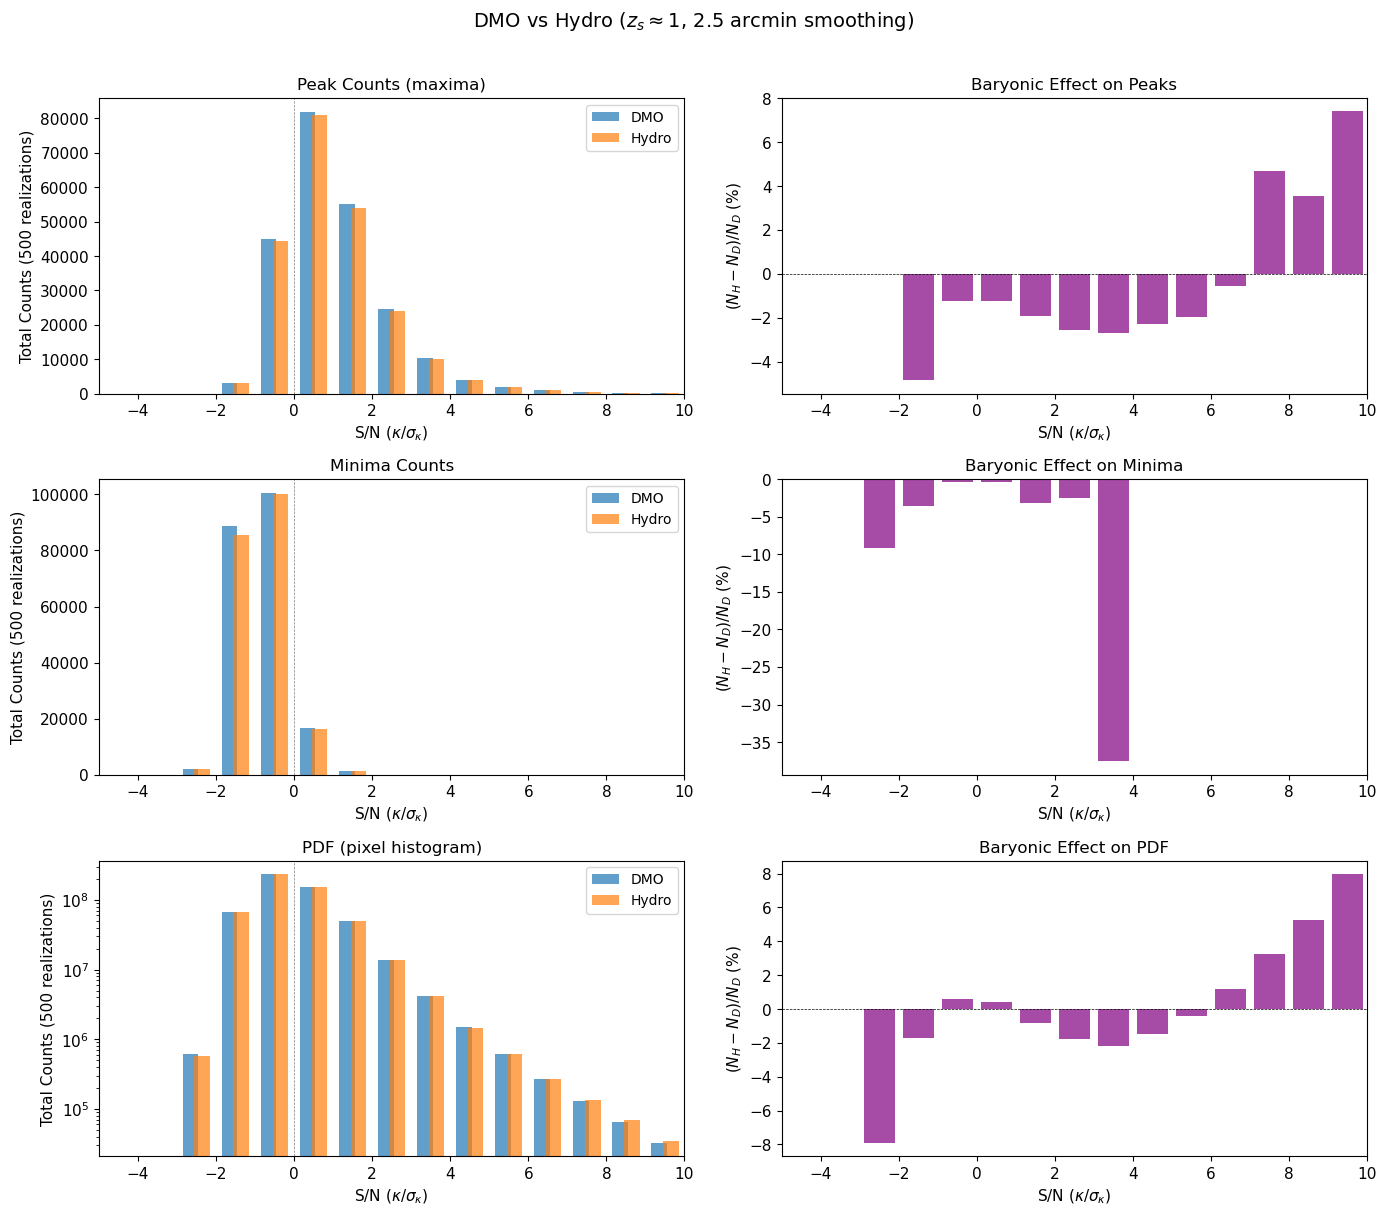

In [48]:
# =============================================================================
# Plot 1: DMO vs Hydro for All Three Statistics
# =============================================================================

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# --- PEAKS (Row 0) ---
ax = axes[0, 0]
width = PEAK_BINS[1] - PEAK_BINS[0]
ax.bar(PEAK_CENTERS - width*0.15, N_D_peaks, width=width*0.4, alpha=0.7, label='DMO', color='C0')
ax.bar(PEAK_CENTERS + width*0.15, N_H_peaks, width=width*0.4, alpha=0.7, label='Hydro', color='C1')
ax.set_xlabel(r'S/N ($\kappa / \sigma_\kappa$)', fontsize=11)
ax.set_ylabel(f'Total Counts ({n_realizations} realizations)', fontsize=11)
ax.set_title(f'Peak Counts (maxima)', fontsize=12)
ax.legend()
ax.set_xlim(PEAK_SN_MIN, PEAK_SN_MAX)
ax.axvline(0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)

ax = axes[0, 1]
rel_diff_peaks = 100 * Delta_N_peaks / N_D_peaks
ax.bar(PEAK_CENTERS, rel_diff_peaks, width=width*0.8, alpha=0.7, color='purple')
ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax.set_xlabel(r'S/N ($\kappa / \sigma_\kappa$)', fontsize=11)
ax.set_ylabel(r'$(N_H - N_D)/N_D$ (%)', fontsize=11)
ax.set_title('Baryonic Effect on Peaks', fontsize=12)
ax.set_xlim(PEAK_SN_MIN, PEAK_SN_MAX)

# --- MINIMA (Row 1) ---
ax = axes[1, 0]
width = MINIMA_BINS[1] - MINIMA_BINS[0]
ax.bar(MINIMA_CENTERS - width*0.15, N_D_minima, width=width*0.4, alpha=0.7, label='DMO', color='C0')
ax.bar(MINIMA_CENTERS + width*0.15, N_H_minima, width=width*0.4, alpha=0.7, label='Hydro', color='C1')
ax.set_xlabel(r'S/N ($\kappa / \sigma_\kappa$)', fontsize=11)
ax.set_ylabel(f'Total Counts ({n_realizations} realizations)', fontsize=11)
ax.set_title(f'Minima Counts', fontsize=12)
ax.legend()
ax.set_xlim(MINIMA_SN_MIN, MINIMA_SN_MAX)
ax.axvline(0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)

ax = axes[1, 1]
rel_diff_minima = 100 * Delta_N_minima / N_D_minima
ax.bar(MINIMA_CENTERS, rel_diff_minima, width=width*0.8, alpha=0.7, color='purple')
ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax.set_xlabel(r'S/N ($\kappa / \sigma_\kappa$)', fontsize=11)
ax.set_ylabel(r'$(N_H - N_D)/N_D$ (%)', fontsize=11)
ax.set_title('Baryonic Effect on Minima', fontsize=12)
ax.set_xlim(MINIMA_SN_MIN, MINIMA_SN_MAX)

# --- PDF (Row 2) ---
ax = axes[2, 0]
width = PDF_BINS[1] - PDF_BINS[0]
ax.bar(PDF_CENTERS - width*0.15, N_D_pdf, width=width*0.4, alpha=0.7, label='DMO', color='C0')
ax.bar(PDF_CENTERS + width*0.15, N_H_pdf, width=width*0.4, alpha=0.7, label='Hydro', color='C1')
ax.set_xlabel(r'S/N ($\kappa / \sigma_\kappa$)', fontsize=11)
ax.set_ylabel(f'Total Counts ({n_realizations} realizations)', fontsize=11)
ax.set_title(f'PDF (pixel histogram)', fontsize=12)
ax.legend()
ax.set_xlim(PDF_SN_MIN, PDF_SN_MAX)
ax.axvline(0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_yscale('log')

ax = axes[2, 1]
rel_diff_pdf = 100 * Delta_N_pdf / N_D_pdf
ax.bar(PDF_CENTERS, rel_diff_pdf, width=width*0.8, alpha=0.7, color='purple')
ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax.set_xlabel(r'S/N ($\kappa / \sigma_\kappa$)', fontsize=11)
ax.set_ylabel(r'$(N_H - N_D)/N_D$ (%)', fontsize=11)
ax.set_title('Baryonic Effect on PDF', fontsize=12)
ax.set_xlim(PDF_SN_MIN, PDF_SN_MAX)

plt.suptitle(f'DMO vs Hydro ($z_s \\approx 1$, {SMOOTHING_ARCMIN} arcmin smoothing)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Plot 2: Response Fraction F vs S/N (Fixed M, Varying R)

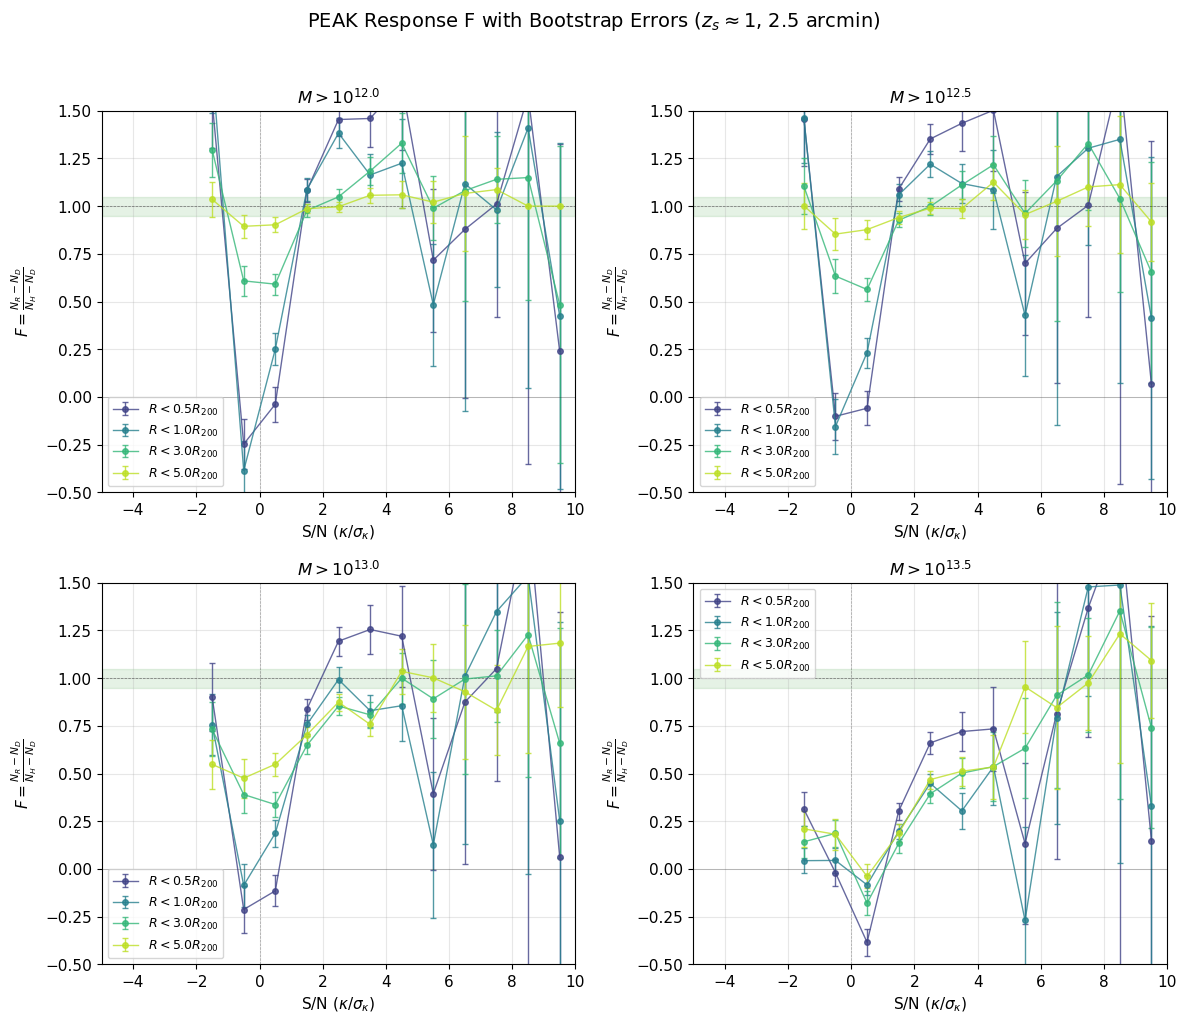

In [49]:
# =============================================================================
# Plot 2: Response Fraction F vs S/N for PEAKS (fixed M, varying R) WITH ERRORS
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

colors_radius = plt.cm.viridis(np.linspace(0.2, 0.9, len(radii_cum)))

for m_idx, (mass_thr, mass_label) in enumerate(zip(mass_thresholds_cum, MASS_LABELS_LOG_CUM)):
    ax = axes[m_idx]
    
    for r_idx, (r, r_label) in enumerate(zip(radii_cum, RADIUS_LABELS_CUM)):
        F_mean = F_grid_peaks_mean[m_idx, r_idx, :]
        F_std = F_grid_peaks_std[m_idx, r_idx, :]
        
        # Only plot where we have valid data
        valid = np.isfinite(F_mean) & np.isfinite(F_std)
        if np.any(valid):
            ax.errorbar(PEAK_CENTERS[valid], F_mean[valid], yerr=F_std[valid],
                       marker='o', markersize=4, linestyle='-', linewidth=1,
                       color=colors_radius[r_idx], label=r_label, alpha=0.8,
                       capsize=2, capthick=1)
    
    ax.axhline(1, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.axvline(0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)
    ax.fill_between([PEAK_SN_MIN, PEAK_SN_MAX], 0.95, 1.05, color='green', alpha=0.1)
    ax.set_xlabel(r'S/N ($\kappa / \sigma_\kappa$)', fontsize=11)
    ax.set_ylabel(r'$F = \frac{N_R - N_D}{N_H - N_D}$', fontsize=11)
    ax.set_title(mass_label, fontsize=12)
    ax.set_xlim(PEAK_SN_MIN, PEAK_SN_MAX)
    ax.set_ylim(-0.5, 1.5)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'PEAK Response F with Bootstrap Errors ($z_s \\approx 1$, {SMOOTHING_ARCMIN} arcmin)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Plot 3: Response Fraction F vs S/N (Fixed R, Varying M)

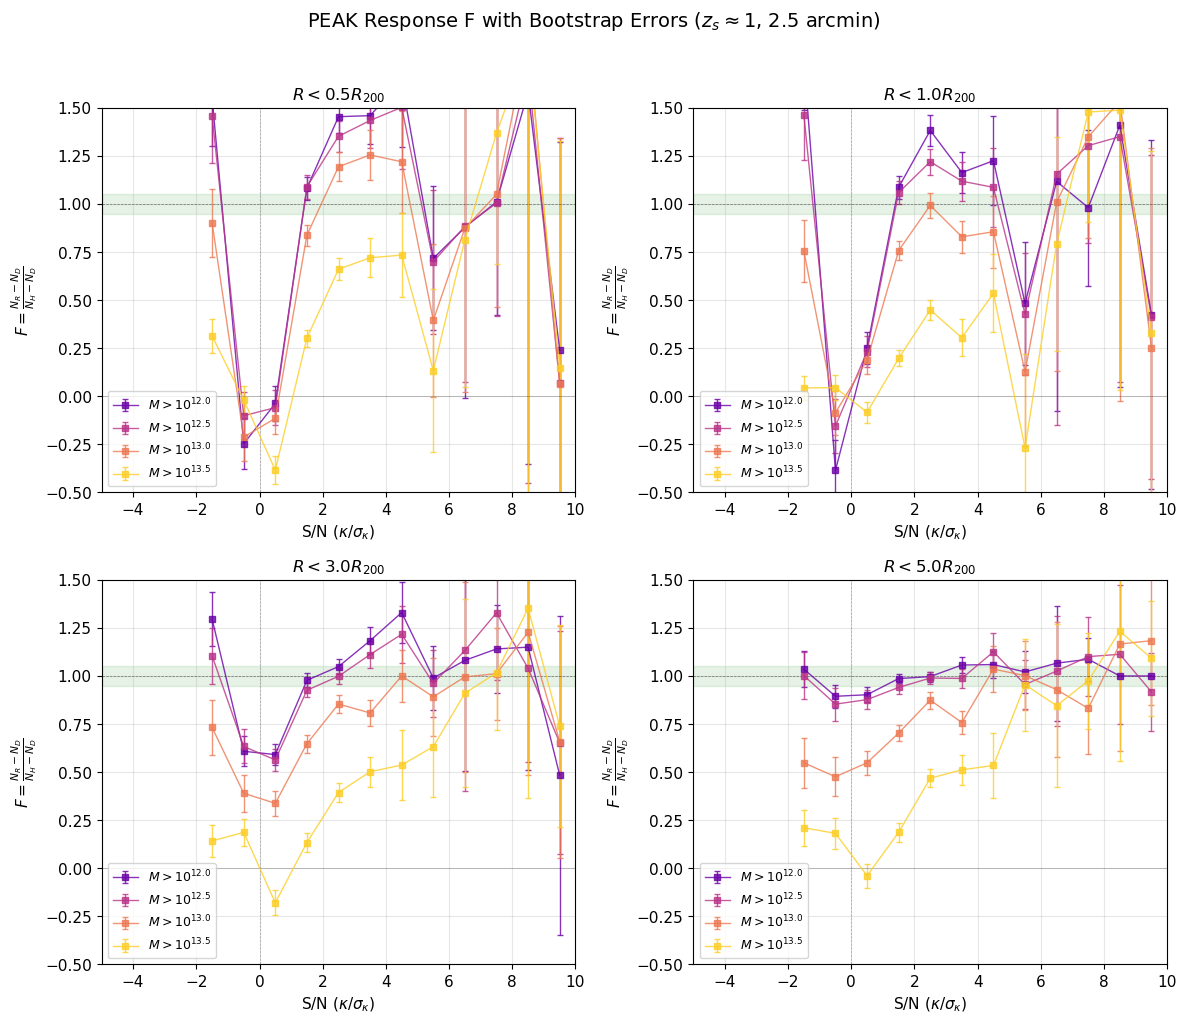

In [50]:
# =============================================================================
# Plot 3: Response Fraction F vs S/N for PEAKS (fixed R, varying M) WITH ERRORS
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

colors_mass = plt.cm.plasma(np.linspace(0.2, 0.9, len(mass_thresholds_cum)))

for r_idx, (r, r_label) in enumerate(zip(radii_cum, RADIUS_LABELS_CUM)):
    ax = axes[r_idx]
    
    for m_idx, (mass_thr, mass_label) in enumerate(zip(mass_thresholds_cum, MASS_LABELS_LOG_CUM)):
        F_mean = F_grid_peaks_mean[m_idx, r_idx, :]
        F_std = F_grid_peaks_std[m_idx, r_idx, :]
        
        # Only plot where we have valid data
        valid = np.isfinite(F_mean) & np.isfinite(F_std)
        if np.any(valid):
            ax.errorbar(PEAK_CENTERS[valid], F_mean[valid], yerr=F_std[valid],
                       marker='s', markersize=4, linestyle='-', linewidth=1,
                       color=colors_mass[m_idx], label=mass_label, alpha=0.8,
                       capsize=2, capthick=1)
    
    ax.axhline(1, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.axvline(0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)
    ax.fill_between([PEAK_SN_MIN, PEAK_SN_MAX], 0.95, 1.05, color='green', alpha=0.1)
    ax.set_xlabel(r'S/N ($\kappa / \sigma_\kappa$)', fontsize=11)
    ax.set_ylabel(r'$F = \frac{N_R - N_D}{N_H - N_D}$', fontsize=11)
    ax.set_title(r_label, fontsize=12)
    ax.set_xlim(PEAK_SN_MIN, PEAK_SN_MAX)
    ax.set_ylim(-0.5, 1.5)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'PEAK Response F with Bootstrap Errors ($z_s \\approx 1$, {SMOOTHING_ARCMIN} arcmin)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Plot 3b: Response Fraction F for MINIMA (Fixed M, Varying R)

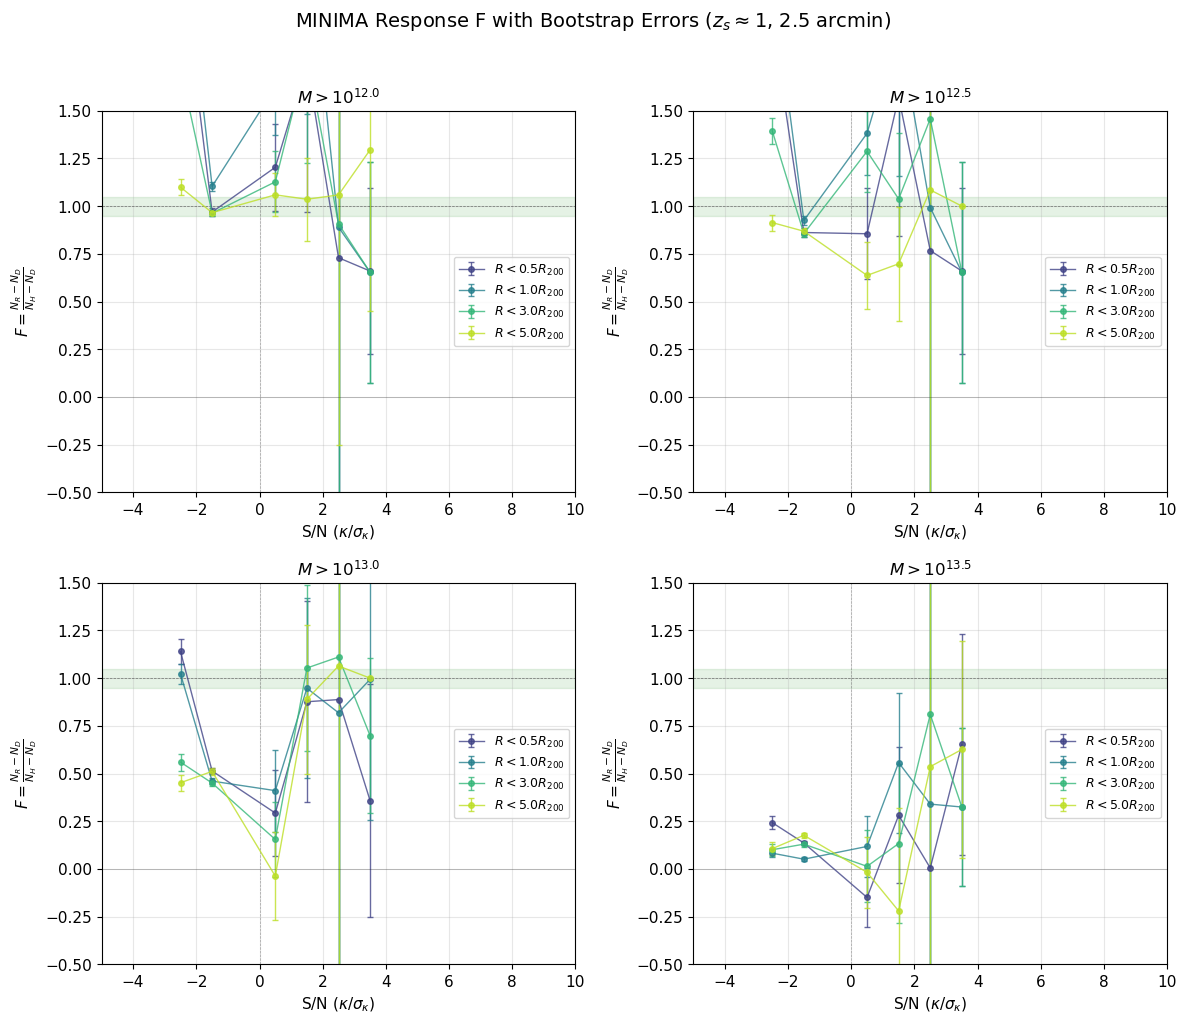

In [51]:
# =============================================================================
# Plot 3b: Response Fraction F for MINIMA (fixed M, varying R) WITH ERRORS
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

colors_radius = plt.cm.viridis(np.linspace(0.2, 0.9, len(radii_cum)))

for m_idx, (mass_thr, mass_label) in enumerate(zip(mass_thresholds_cum, MASS_LABELS_LOG_CUM)):
    ax = axes[m_idx]
    
    for r_idx, (r, r_label) in enumerate(zip(radii_cum, RADIUS_LABELS_CUM)):
        F_mean = F_grid_minima_mean[m_idx, r_idx, :]
        F_std = F_grid_minima_std[m_idx, r_idx, :]
        
        valid = np.isfinite(F_mean) & np.isfinite(F_std)
        if np.any(valid):
            ax.errorbar(MINIMA_CENTERS[valid], F_mean[valid], yerr=F_std[valid],
                       marker='o', markersize=4, linestyle='-', linewidth=1,
                       color=colors_radius[r_idx], label=r_label, alpha=0.8,
                       capsize=2, capthick=1)
    
    ax.axhline(1, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.axvline(0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)
    ax.fill_between([MINIMA_SN_MIN, MINIMA_SN_MAX], 0.95, 1.05, color='green', alpha=0.1)
    ax.set_xlabel(r'S/N ($\kappa / \sigma_\kappa$)', fontsize=11)
    ax.set_ylabel(r'$F = \frac{N_R - N_D}{N_H - N_D}$', fontsize=11)
    ax.set_title(mass_label, fontsize=12)
    ax.set_xlim(MINIMA_SN_MIN, MINIMA_SN_MAX)
    ax.set_ylim(-0.5, 1.5)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'MINIMA Response F with Bootstrap Errors ($z_s \\approx 1$, {SMOOTHING_ARCMIN} arcmin)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Plot 3c: Response Fraction F for PDF (Fixed M, Varying R)

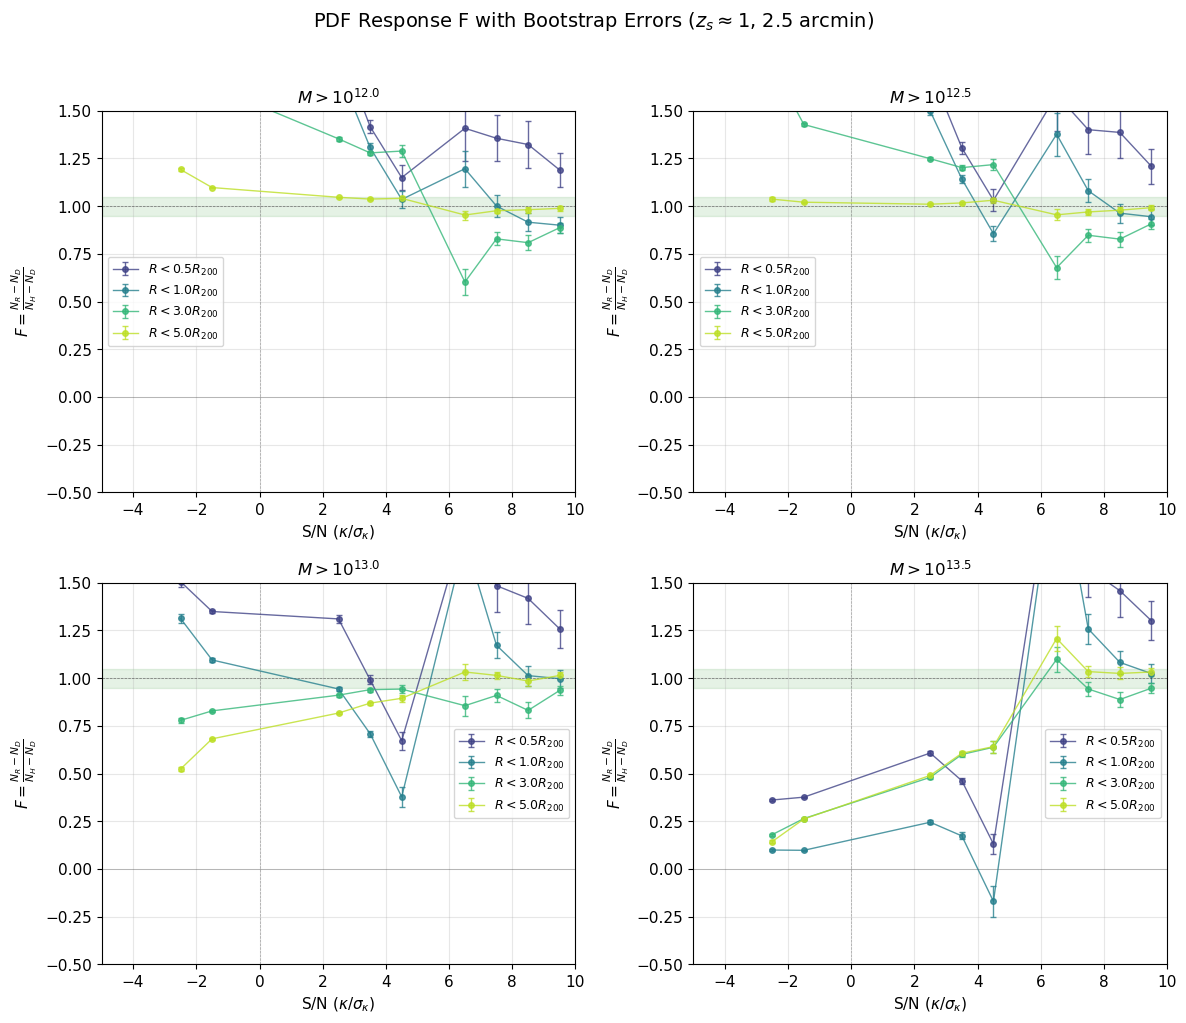

In [52]:
# =============================================================================
# Plot 3c: Response Fraction F for PDF (fixed M, varying R) WITH ERRORS
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

colors_radius = plt.cm.viridis(np.linspace(0.2, 0.9, len(radii_cum)))

for m_idx, (mass_thr, mass_label) in enumerate(zip(mass_thresholds_cum, MASS_LABELS_LOG_CUM)):
    ax = axes[m_idx]
    
    for r_idx, (r, r_label) in enumerate(zip(radii_cum, RADIUS_LABELS_CUM)):
        F_mean = F_grid_pdf_mean[m_idx, r_idx, :]
        F_std = F_grid_pdf_std[m_idx, r_idx, :]
        
        valid = np.isfinite(F_mean) & np.isfinite(F_std)
        if np.any(valid):
            ax.errorbar(PDF_CENTERS[valid], F_mean[valid], yerr=F_std[valid],
                       marker='o', markersize=4, linestyle='-', linewidth=1,
                       color=colors_radius[r_idx], label=r_label, alpha=0.8,
                       capsize=2, capthick=1)
    
    ax.axhline(1, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.axvline(0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)
    ax.fill_between([PDF_SN_MIN, PDF_SN_MAX], 0.95, 1.05, color='green', alpha=0.1)
    ax.set_xlabel(r'S/N ($\kappa / \sigma_\kappa$)', fontsize=11)
    ax.set_ylabel(r'$F = \frac{N_R - N_D}{N_H - N_D}$', fontsize=11)
    ax.set_title(mass_label, fontsize=12)
    ax.set_xlim(PDF_SN_MIN, PDF_SN_MAX)
    ax.set_ylim(-0.5, 1.5)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'PDF Response F with Bootstrap Errors ($z_s \\approx 1$, {SMOOTHING_ARCMIN} arcmin)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Plot 4: Cumulative F Heatmap (Weighted by Baryonic Effect)

Computing weighted F with bootstrap errors for all statistics...


/tmp/ipykernel_2115398/3039472932.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


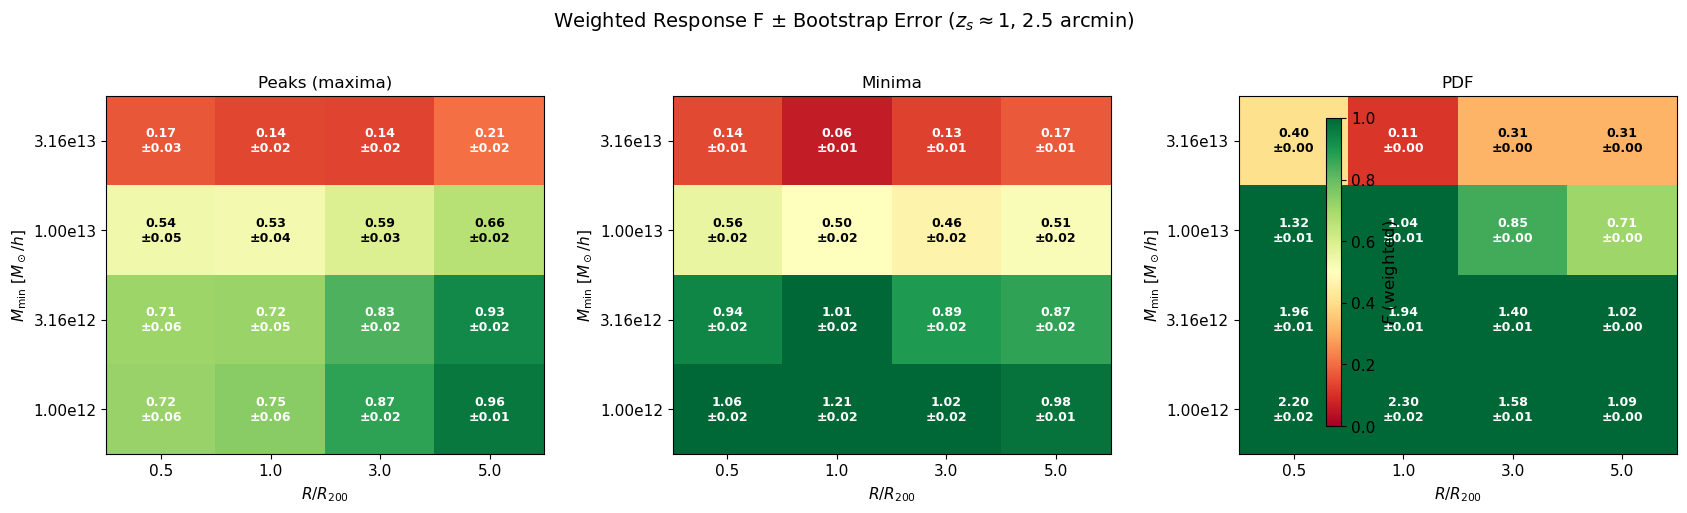


Weighted Cumulative F ± Bootstrap Error:

Peaks:
  M > 1.00e12: R=[0.72±0.06, 0.75±0.06, 0.87±0.02, 0.96±0.01]
  M > 3.16e12: R=[0.71±0.06, 0.72±0.05, 0.83±0.02, 0.93±0.02]
  M > 1.00e13: R=[0.54±0.05, 0.53±0.04, 0.59±0.03, 0.66±0.02]
  M > 3.16e13: R=[0.17±0.03, 0.14±0.02, 0.14±0.02, 0.21±0.02]

Minima:
  M > 1.00e12: R=[1.06±0.02, 1.21±0.02, 1.02±0.02, 0.98±0.01]
  M > 3.16e12: R=[0.94±0.02, 1.01±0.02, 0.89±0.02, 0.87±0.02]
  M > 1.00e13: R=[0.56±0.02, 0.50±0.02, 0.46±0.02, 0.51±0.02]
  M > 3.16e13: R=[0.14±0.01, 0.06±0.01, 0.13±0.01, 0.17±0.01]

PDF:
  M > 1.00e12: R=[2.20±0.02, 2.30±0.02, 1.58±0.01, 1.09±0.00]
  M > 3.16e12: R=[1.96±0.01, 1.94±0.01, 1.40±0.01, 1.02±0.00]
  M > 1.00e13: R=[1.32±0.01, 1.04±0.01, 0.85±0.00, 0.71±0.00]
  M > 3.16e13: R=[0.40±0.00, 0.11±0.00, 0.31±0.00, 0.31±0.00]


In [53]:
# =============================================================================
# Plot 4: Cumulative F Heatmaps for All Three Statistics WITH BOOTSTRAP ERRORS
# =============================================================================

# Compute weighted F with bootstrap errors for all three statistics
print("Computing weighted F with bootstrap errors for all statistics...")

F_weighted_peaks_mean = np.zeros((len(mass_thresholds_cum), len(radii_cum)))
F_weighted_peaks_std = np.zeros((len(mass_thresholds_cum), len(radii_cum)))
F_weighted_minima_mean = np.zeros((len(mass_thresholds_cum), len(radii_cum)))
F_weighted_minima_std = np.zeros((len(mass_thresholds_cum), len(radii_cum)))
F_weighted_pdf_mean = np.zeros((len(mass_thresholds_cum), len(radii_cum)))
F_weighted_pdf_std = np.zeros((len(mass_thresholds_cum), len(radii_cum)))

for m_idx, mass_thr in enumerate(mass_thresholds_cum):
    for r_idx, r in enumerate(radii_cum):
        model = f'hydro_replace_Ml_{mass_thr}_Mu_inf_R_{r}'
        
        # Peaks
        data_R = peak_counts_sn[model]
        F_mean, F_std, _ = bootstrap_weighted_F(data_R, data_D_peaks, data_H_peaks, 
                                                  n_bootstrap=1000)
        F_weighted_peaks_mean[m_idx, r_idx] = F_mean
        F_weighted_peaks_std[m_idx, r_idx] = F_std
        
        # Minima
        data_R = minima_counts_sn[model]
        F_mean, F_std, _ = bootstrap_weighted_F(data_R, data_D_minima, data_H_minima, 
                                                  n_bootstrap=1000)
        F_weighted_minima_mean[m_idx, r_idx] = F_mean
        F_weighted_minima_std[m_idx, r_idx] = F_std
        
        # PDF
        data_R = pdf_counts_sn[model]
        F_mean, F_std, _ = bootstrap_weighted_F(data_R, data_D_pdf, data_H_pdf, 
                                                  n_bootstrap=1000)
        F_weighted_pdf_mean[m_idx, r_idx] = F_mean
        F_weighted_pdf_std[m_idx, r_idx] = F_std

# Legacy aliases (no errors)
F_weighted_peaks = F_weighted_peaks_mean
F_weighted_minima = F_weighted_minima_mean
F_weighted_pdf = F_weighted_pdf_mean
F_weighted_grid = F_weighted_peaks

# Plot heatmaps with errors for all three
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (F_mean_data, F_std_data), title in zip(
    axes, 
    [(F_weighted_peaks_mean, F_weighted_peaks_std), 
     (F_weighted_minima_mean, F_weighted_minima_std), 
     (F_weighted_pdf_mean, F_weighted_pdf_std)],
    ['Peaks (maxima)', 'Minima', 'PDF']):
    
    im = ax.imshow(F_mean_data, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
    
    for i in range(len(mass_thresholds_cum)):
        for j in range(len(radii_cum)):
            val = F_mean_data[i, j]
            err = F_std_data[i, j]
            text_color = 'white' if val < 0.3 or val > 0.7 else 'black'
            ax.text(j, i, f'{val:.2f}\n±{err:.2f}', ha='center', va='center', 
                    color=text_color, fontsize=9, fontweight='bold')
    
    ax.set_xticks(range(len(radii_cum)))
    ax.set_xticklabels([f'{r}' for r in radii_cum])
    ax.set_yticks(range(len(mass_thresholds_cum)))
    ax.set_yticklabels([f'{m}' for m in mass_thresholds_cum])
    ax.set_xlabel(r'$R/R_{200}$', fontsize=11)
    ax.set_ylabel(r'$M_{\min}$ [$M_\odot/h$]', fontsize=11)
    ax.set_title(title, fontsize=12)

fig.colorbar(im, ax=axes, label=r'$F$ (weighted)', shrink=0.8)
plt.suptitle(f'Weighted Response F ± Bootstrap Error ($z_s \\approx 1$, {SMOOTHING_ARCMIN} arcmin)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print summary with errors
print("\nWeighted Cumulative F ± Bootstrap Error:")
print("=" * 90)
for stat_name, F_mean_data, F_std_data in [
    ('Peaks', F_weighted_peaks_mean, F_weighted_peaks_std), 
    ('Minima', F_weighted_minima_mean, F_weighted_minima_std), 
    ('PDF', F_weighted_pdf_mean, F_weighted_pdf_std)]:
    print(f"\n{stat_name}:")
    for m_idx, mass_thr in enumerate(mass_thresholds_cum):
        vals = [f"{F_mean_data[m_idx, r_idx]:.2f}±{F_std_data[m_idx, r_idx]:.2f}" 
                for r_idx in range(len(radii_cum))]
        print(f"  M > {mass_thr}: R=[{', '.join(vals)}]")

## Analysis by Peak Type

Categorize peaks by S/N to understand the response for different physical structures:
- **Negative (voids)**: S/N < 0 - underdense regions
- **Low**: 0 < S/N < 2 - moderate overdensities
- **Intermediate**: 2 < S/N < 5 - groups and filaments
- **High (clusters)**: S/N > 5 - massive clusters

In [54]:
# =============================================================================
# Analysis: F by Peak Type (Negative, Low, Intermediate, High S/N) WITH ERRORS
# =============================================================================

# Define S/N ranges for different peak types
SN_PEAK_TYPES = {
    'Negative (voids)': (SN_MIN, 0.0),
    'Low': (0.0, 2.0),
    'Intermediate': (2.0, 5.0),
    'High (clusters)': (5.0, SN_MAX),
}

def bootstrap_F_by_peak_type(model_name, peak_types=SN_PEAK_TYPES, n_bootstrap=1000):
    """
    Compute F and bootstrap error for different peak types.
    
    Returns:
    --------
    dict of {ptype: (F_mean, F_std)}
    """
    n_lp, n_runs, n_bins = peak_counts_sn['dmo'].shape
    n_realizations = n_lp * n_runs
    
    # Flatten all data
    R_flat = peak_counts_sn[model_name].reshape(n_realizations, n_bins)
    D_flat = peak_counts_sn['dmo'].reshape(n_realizations, n_bins)
    H_flat = peak_counts_sn['hydro'].reshape(n_realizations, n_bins)
    
    rng = np.random.default_rng(42)
    
    results = {}
    for ptype, (sn_min, sn_max) in peak_types.items():
        mask = (SN_CENTERS >= sn_min) & (SN_CENTERS < sn_max)
        
        if not np.any(mask):
            results[ptype] = (np.nan, np.nan)
            continue
        
        F_samples = np.zeros(n_bootstrap)
        for i in range(n_bootstrap):
            idx = rng.choice(n_realizations, size=n_realizations, replace=True)
            
            N_R_sum = np.sum(R_flat[idx][:, mask])
            N_D_sum = np.sum(D_flat[idx][:, mask])
            N_H_sum = np.sum(H_flat[idx][:, mask])
            
            Delta_N = N_H_sum - N_D_sum
            if np.abs(Delta_N) < 10:
                F_samples[i] = np.nan
            else:
                F_samples[i] = (N_R_sum - N_D_sum) / Delta_N
        
        results[ptype] = (np.nanmean(F_samples), np.nanstd(F_samples))
    
    return results

# Legacy function (no errors)
def compute_F_by_peak_type(model_name, peak_types=SN_PEAK_TYPES):
    """Compute F for different peak types (no errors)."""
    result = bootstrap_F_by_peak_type(model_name, peak_types, n_bootstrap=100)
    return {k: v[0] for k, v in result.items()}

# Compute for all models WITH ERRORS
print("Computing F by peak type with bootstrap errors...")
F_by_type_all = {}  # {model: {ptype: (F_mean, F_std)}}

for model in tqdm(['dmo', 'hydro'] + CUMULATIVE_MODELS, desc="Peak types"):
    F_by_type_all[model] = bootstrap_F_by_peak_type(model, n_bootstrap=500)

# Print baryonic effect by peak type
print("\nBaryonic Effect by Peak Type (S/N bins):")
print("=" * 60)
for ptype, (sn_min, sn_max) in SN_PEAK_TYPES.items():
    mask = (SN_CENTERS >= sn_min) & (SN_CENTERS < sn_max)
    N_D_sum = np.sum(N_D[mask])
    N_H_sum = np.sum(N_H[mask])
    Delta_N_sum = N_H_sum - N_D_sum
    pct = 100 * Delta_N_sum / N_D_sum if N_D_sum > 0 else 0
    print(f"{ptype:20s}: ΔN = {Delta_N_sum:+8.0f} ({pct:+5.1f}%)")
    print(f"                      N_D = {N_D_sum:8.0f}, N_H = {N_H_sum:8.0f}")
print()

Computing F by peak type with bootstrap errors...


Peak types: 100%|██████████| 18/18 [00:02<00:00,  7.78it/s]


Baryonic Effect by Peak Type (S/N bins):
Negative (voids)    : ΔN =     -712 ( -1.5%)
                      N_D =    48262, N_H =    47550
Low                 : ΔN =    -2073 ( -1.5%)
                      N_D =   136931, N_H =   134858
Intermediate        : ΔN =    -1001 ( -2.6%)
                      N_D =    38842, N_H =    37841
High (clusters)     : ΔN =       +2 ( +0.1%)
                      N_D =     3871, N_H =     3873



/tmp/ipykernel_2115398/4086584900.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 0.95])


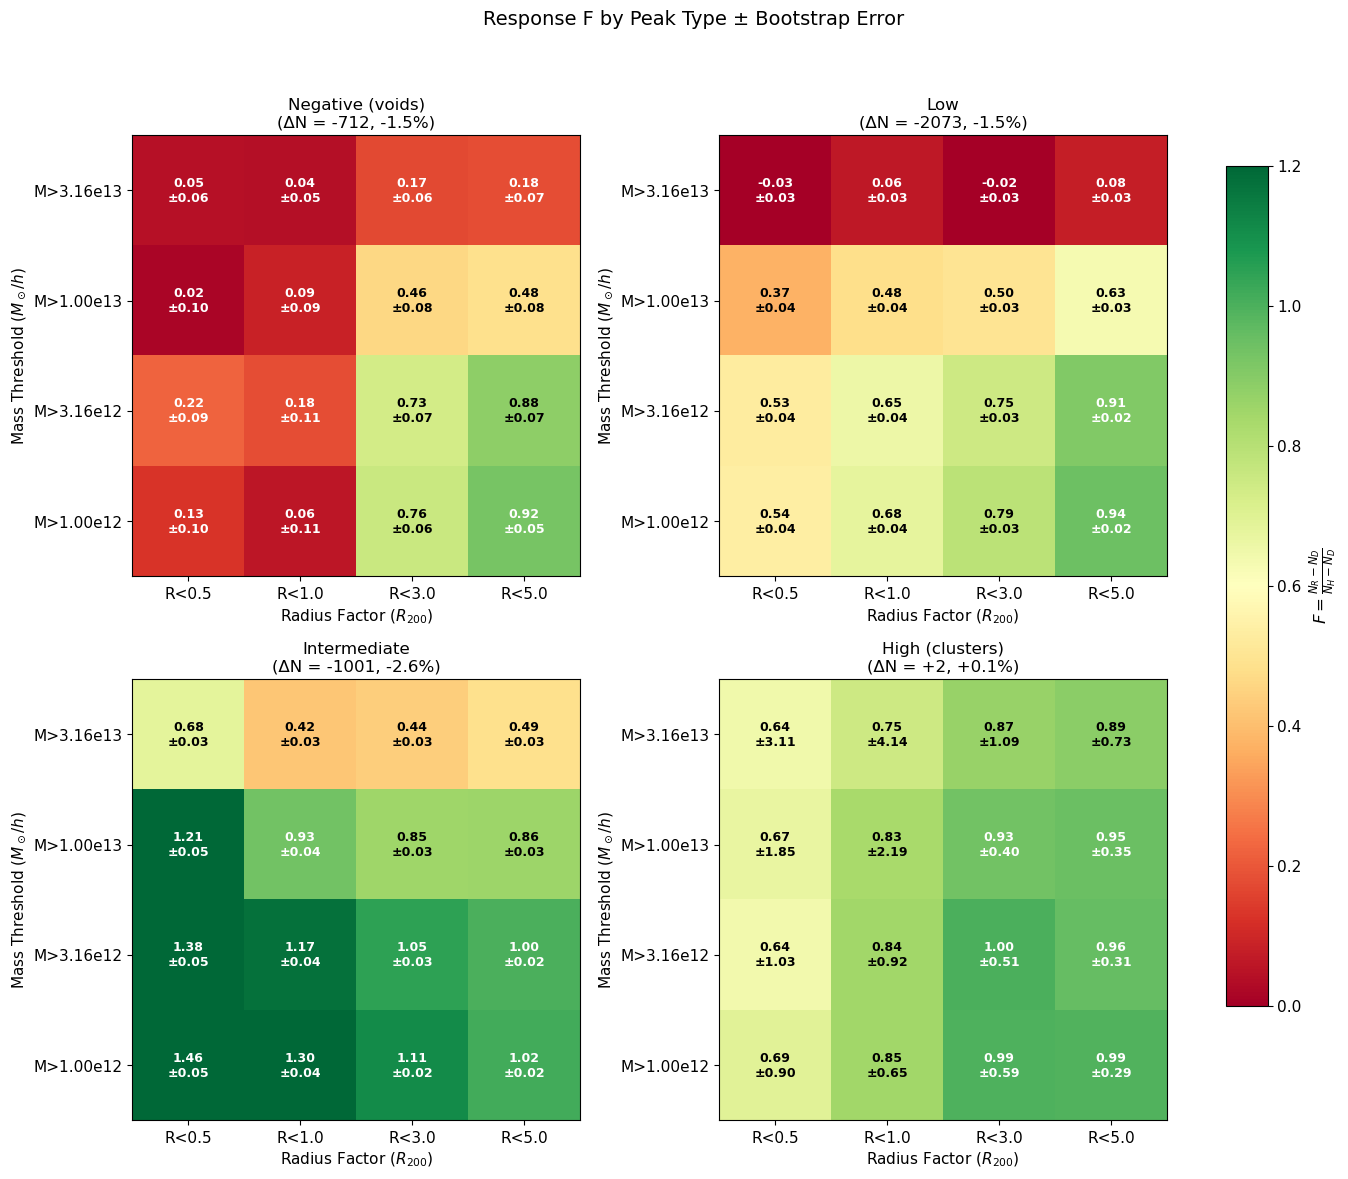

In [55]:
# =============================================================================
# Plot: F by Peak Type - Heatmap for each peak category WITH ERRORS
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

sn_type_names = list(SN_PEAK_TYPES.keys())

for pt_idx, ptype in enumerate(sn_type_names):
    ax = axes[pt_idx]
    
    # Build F grid with errors for this peak type
    F_pt_grid_mean = np.zeros((len(mass_thresholds_cum), len(radii_cum)))
    F_pt_grid_std = np.zeros((len(mass_thresholds_cum), len(radii_cum)))
    
    for m_idx, mass_thr in enumerate(mass_thresholds_cum):
        for r_idx, r in enumerate(radii_cum):
            model = f'hydro_replace_Ml_{mass_thr}_Mu_inf_R_{r}'
            F_mean, F_std = F_by_type_all[model].get(ptype, (np.nan, np.nan))
            F_pt_grid_mean[m_idx, r_idx] = F_mean
            F_pt_grid_std[m_idx, r_idx] = F_std
    
    # Plot heatmap
    im = ax.imshow(F_pt_grid_mean, cmap='RdYlGn', vmin=0, vmax=1.2, aspect='auto', origin='lower')
    
    # Add text annotations with errors
    for i in range(len(mass_thresholds_cum)):
        for j in range(len(radii_cum)):
            val = F_pt_grid_mean[i, j]
            err = F_pt_grid_std[i, j]
            if np.isfinite(val):
                text_color = 'white' if val < 0.3 or val > 0.9 else 'black'
                ax.text(j, i, f'{val:.2f}\n±{err:.2f}', ha='center', va='center', 
                        color=text_color, fontsize=9, fontweight='bold')
            else:
                ax.text(j, i, 'N/A', ha='center', va='center', 
                        color='gray', fontsize=10)
    
    ax.set_xticks(range(len(radii_cum)))
    ax.set_xticklabels([f'R<{r}' for r in radii_cum])
    ax.set_yticks(range(len(mass_thresholds_cum)))
    ax.set_yticklabels([f'M>{m}' for m in mass_thresholds_cum])
    ax.set_xlabel(r'Radius Factor ($R_{200}$)', fontsize=11)
    ax.set_ylabel(r'Mass Threshold ($M_\odot/h$)', fontsize=11)
    
    # Get baryonic effect for title
    sn_min, sn_max = SN_PEAK_TYPES[ptype]
    mask = (SN_CENTERS >= sn_min) & (SN_CENTERS < sn_max)
    Delta_N_sum = np.sum(N_H[mask]) - np.sum(N_D[mask])
    pct = 100 * Delta_N_sum / np.sum(N_D[mask]) if np.sum(N_D[mask]) > 0 else 0
    ax.set_title(f'{ptype}\n(ΔN = {Delta_N_sum:+.0f}, {pct:+.1f}%)', fontsize=12)

# Add colorbar
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r'$F = \frac{N_R - N_D}{N_H - N_D}$', fontsize=12)

plt.suptitle('Response F by Peak Type ± Bootstrap Error', fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

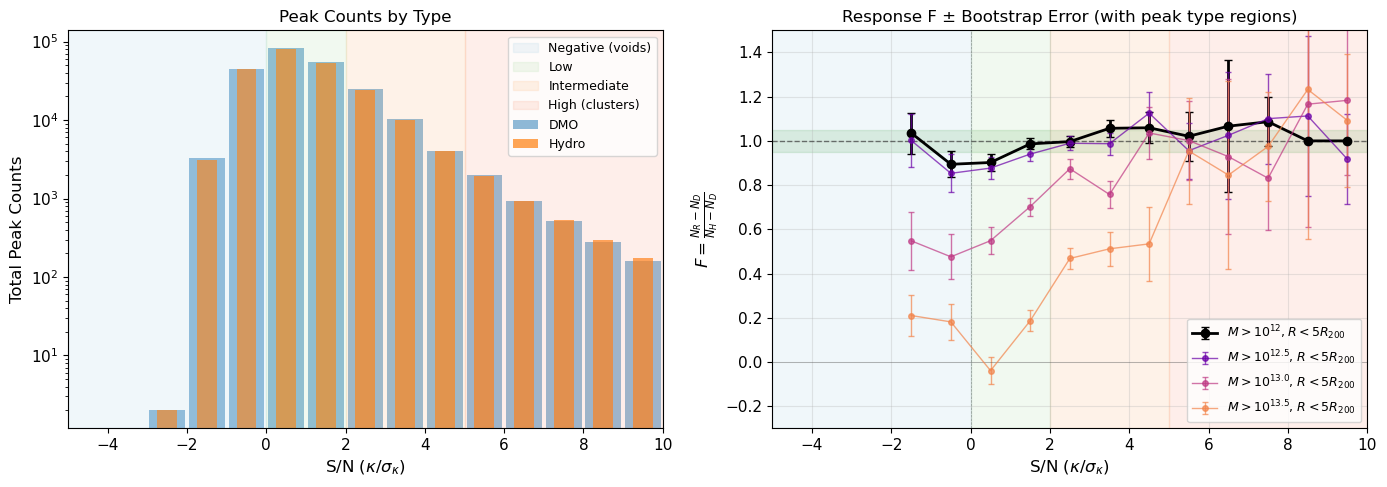

In [56]:
# =============================================================================
# Plot: F vs S/N with Peak Type Regions Highlighted WITH ERRORS
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Peak counts with regions
ax = axes[0]
width_sn = SN_BINS[1] - SN_BINS[0]
ax.bar(SN_CENTERS, N_D, width=width_sn*0.9, alpha=0.5, label='DMO', color='C0')
ax.bar(SN_CENTERS, N_H, width=width_sn*0.5, alpha=0.7, label='Hydro', color='C1')

# Shade regions
colors_region = ['#9ecae1', '#a1d99b', '#fdae6b', '#fc9272']
for i, (ptype, (sn_min, sn_max)) in enumerate(SN_PEAK_TYPES.items()):
    ax.axvspan(sn_min, sn_max, alpha=0.15, color=colors_region[i], label=ptype)

ax.set_xlabel(r'S/N ($\kappa / \sigma_\kappa$)', fontsize=12)
ax.set_ylabel(f'Total Peak Counts', fontsize=12)
ax.set_title('Peak Counts by Type', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(SN_MIN, SN_MAX)
ax.set_yscale('log')

# Right: F vs S/N for the full model with regions AND ERROR BARS
ax = axes[1]

# Plot F for M > 10^12, R < 5 R200 (most complete) with errors
model_full = 'hydro_replace_Ml_1.00e12_Mu_inf_R_5.0'
F_mean, F_std = F_peaks_bootstrap[model_full]
valid = np.isfinite(F_mean) & np.isfinite(F_std)

ax.errorbar(PEAK_CENTERS[valid], F_mean[valid], yerr=F_std[valid],
            fmt='ko-', markersize=6, linewidth=2, capsize=3, capthick=1,
            label=r'$M > 10^{12}, R < 5R_{200}$')

# Also plot for other mass thresholds at R < 5 with errors
for m_idx, (mass_thr, mass_label) in enumerate(zip(mass_thresholds_cum[1:], MASS_LABELS_LOG_CUM[1:])):
    model = f'hydro_replace_Ml_{mass_thr}_Mu_inf_R_5.0'
    F_mean, F_std = F_peaks_bootstrap[model]
    valid = np.isfinite(F_mean) & np.isfinite(F_std)
    ax.errorbar(PEAK_CENTERS[valid], F_mean[valid], yerr=F_std[valid],
                fmt='o-', markersize=4, linewidth=1, capsize=2, capthick=1,
                alpha=0.7, color=plt.cm.plasma(0.2 + 0.25*m_idx), 
                label=mass_label + r', $R<5R_{200}$')

# Shade regions
for i, (ptype, (sn_min, sn_max)) in enumerate(SN_PEAK_TYPES.items()):
    ax.axvspan(sn_min, sn_max, alpha=0.15, color=colors_region[i])

ax.axhline(1, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
ax.axvline(0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)
ax.fill_between([SN_MIN, SN_MAX], 0.95, 1.05, color='green', alpha=0.1)
ax.set_xlabel(r'S/N ($\kappa / \sigma_\kappa$)', fontsize=12)
ax.set_ylabel(r'$F = \frac{N_R - N_D}{N_H - N_D}$', fontsize=12)
ax.set_title('Response F ± Bootstrap Error (with peak type regions)', fontsize=12)
ax.legend(fontsize=9, loc='best')
ax.set_xlim(SN_MIN, SN_MAX)
ax.set_ylim(-0.3, 1.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [57]:
# =============================================================================
# Summary Table: F by Peak Type for key models WITH ERRORS
# =============================================================================

print("=" * 110)
print("Response Fraction F ± Bootstrap Error by Peak Type")
print("=" * 110)
print(f"{'Model':<35} {'Negative (S/N<0)':<20} {'Low (0-2)':<18} {'Intermediate (2-5)':<20} {'High (S/N>5)':<18}")
print("-" * 110)

# Key models to display
key_models = [
    ('hydro_replace_Ml_1.00e12_Mu_inf_R_5.0', r'M > 10^12, R < 5'),
    ('hydro_replace_Ml_1.00e12_Mu_inf_R_1.0', r'M > 10^12, R < 1'),
    ('hydro_replace_Ml_3.16e12_Mu_inf_R_5.0', r'M > 10^12.5, R < 5'),
    ('hydro_replace_Ml_1.00e13_Mu_inf_R_5.0', r'M > 10^13, R < 5'),
    ('hydro_replace_Ml_3.16e13_Mu_inf_R_5.0', r'M > 10^13.5, R < 5'),
]

for model, label in key_models:
    F_types = F_by_type_all[model]
    vals_str = []
    for pt in SN_PEAK_TYPES.keys():
        F_mean, F_std = F_types.get(pt, (np.nan, np.nan))
        if np.isfinite(F_mean):
            vals_str.append(f'{F_mean:.2f}±{F_std:.2f}')
        else:
            vals_str.append('N/A')
    print(f"{label:<35} {vals_str[0]:<20} {vals_str[1]:<18} {vals_str[2]:<20} {vals_str[3]:<18}")

print("=" * 110)
print("\nInterpretation:")
print("- F ≈ 1: Replace model fully captures baryonic effect")
print("- F < 1: Replace model only partially captures effect") 
print("- F > 1: Replace model overcorrects")
print("- Errors show 1σ bootstrap uncertainty from 500 realizations")
print("- Negative peaks (S/N < 0) probe voids (emptier regions)")
print("- High peaks (S/N > 5) probe clusters (dense regions)")

Response Fraction F ± Bootstrap Error by Peak Type
Model                               Negative (S/N<0)     Low (0-2)          Intermediate (2-5)   High (S/N>5)      
--------------------------------------------------------------------------------------------------------------
M > 10^12, R < 5                    0.92±0.05            0.94±0.02          1.02±0.02            0.99±0.29         
M > 10^12, R < 1                    0.06±0.11            0.68±0.04          1.30±0.04            0.85±0.65         
M > 10^12.5, R < 5                  0.88±0.07            0.91±0.02          1.00±0.02            0.96±0.31         
M > 10^13, R < 5                    0.48±0.08            0.63±0.03          0.86±0.03            0.95±0.35         
M > 10^13.5, R < 5                  0.18±0.07            0.08±0.03          0.49±0.03            0.89±0.73         

Interpretation:
- F ≈ 1: Replace model fully captures baryonic effect
- F < 1: Replace model only partially captures effect
- F > 1: Replace 

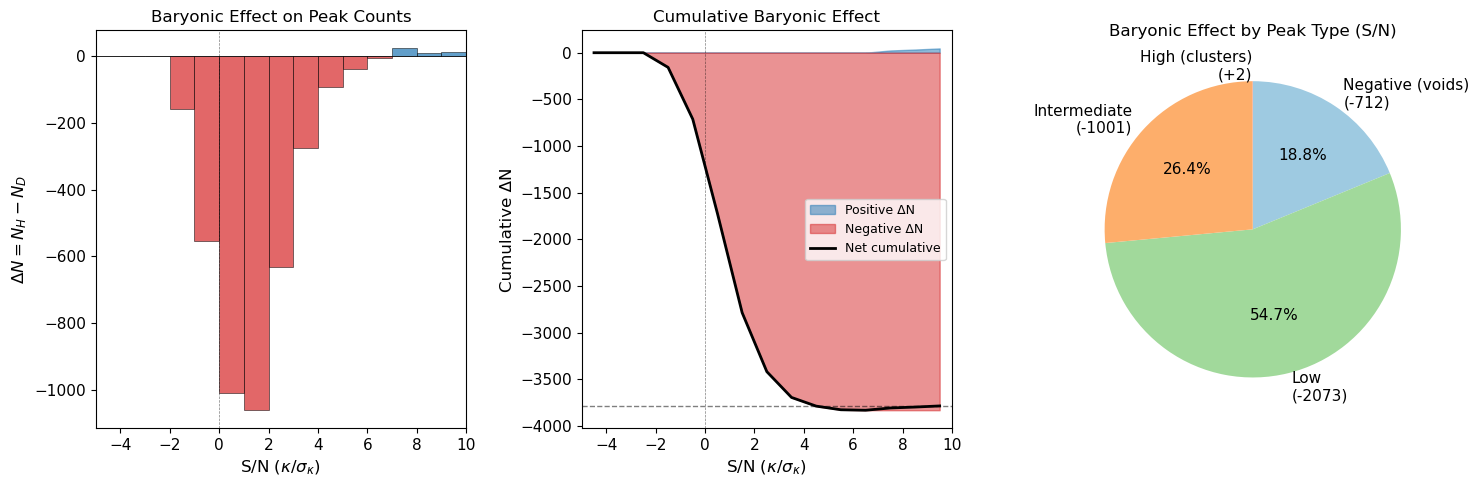


Baryonic Effect Breakdown (S/N bins):
--------------------------------------------------
Negative (voids)    : ΔN =     -712 ( 18.8% of |total|)
Low                 : ΔN =    -2073 ( 54.7% of |total|)
Intermediate        : ΔN =    -1001 ( 26.4% of |total|)
High (clusters)     : ΔN =       +2 (  0.1% of |total|)


In [58]:
# =============================================================================
# Plot: Contribution to total baryonic effect by S/N bin
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Left: ΔN = N_H - N_D by S/N bin
ax = axes[0]
colors = ['C0' if dn > 0 else 'C3' for dn in Delta_N]
width_sn = SN_BINS[1] - SN_BINS[0]
ax.bar(SN_CENTERS, Delta_N, width=width_sn, color=colors, alpha=0.7, edgecolor='k', linewidth=0.5)
ax.axhline(0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_xlabel(r'S/N ($\kappa / \sigma_\kappa$)', fontsize=12)
ax.set_ylabel(r'$\Delta N = N_H - N_D$', fontsize=12)
ax.set_title('Baryonic Effect on Peak Counts', fontsize=12)
ax.set_xlim(SN_MIN, SN_MAX)

# Middle: Cumulative contribution to baryonic effect
ax = axes[1]
cumsum_pos = np.cumsum(np.maximum(Delta_N, 0))
cumsum_neg = np.cumsum(np.minimum(Delta_N, 0))
total_effect = np.sum(Delta_N)

ax.fill_between(SN_CENTERS, 0, cumsum_pos, alpha=0.5, color='C0', label='Positive ΔN')
ax.fill_between(SN_CENTERS, 0, cumsum_neg, alpha=0.5, color='C3', label='Negative ΔN')
ax.plot(SN_CENTERS, cumsum_pos + cumsum_neg, 'k-', linewidth=2, label='Net cumulative')
ax.axhline(total_effect, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_xlabel(r'S/N ($\kappa / \sigma_\kappa$)', fontsize=12)
ax.set_ylabel('Cumulative ΔN', fontsize=12)
ax.set_title('Cumulative Baryonic Effect', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(SN_MIN, SN_MAX)

# Right: Pie chart of effect by peak type
ax = axes[2]
effect_by_type = []
labels_pie = []
for ptype, (sn_min, sn_max) in SN_PEAK_TYPES.items():
    mask = (SN_CENTERS >= sn_min) & (SN_CENTERS < sn_max)
    effect = np.sum(Delta_N[mask])
    effect_by_type.append(effect)
    labels_pie.append(f'{ptype}\n({effect:+.0f})')

# Use absolute values for pie chart size, color by sign
colors_pie = ['#9ecae1', '#a1d99b', '#fdae6b', '#fc9272']
abs_effects = [abs(e) for e in effect_by_type]

wedges, texts, autotexts = ax.pie(abs_effects, labels=labels_pie, colors=colors_pie, 
                                   autopct=lambda p: f'{p:.1f}%' if p > 5 else '',
                                   startangle=90, counterclock=False)
ax.set_title('Baryonic Effect by Peak Type (S/N)', fontsize=12)

plt.tight_layout()
plt.show()

# Print breakdown
print("\nBaryonic Effect Breakdown (S/N bins):")
print("-" * 50)
total_abs = np.sum([abs(e) for e in effect_by_type])
for ptype, effect in zip(SN_PEAK_TYPES.keys(), effect_by_type):
    pct_of_total = 100 * abs(effect) / total_abs if total_abs > 0 else 0
    print(f"{ptype:20s}: ΔN = {effect:+8.0f} ({pct_of_total:5.1f}% of |total|)")

In [59]:
# =============================================================================
# Debug: Understanding PDF F > 1
# =============================================================================

print("PDF Statistics Diagnosis:")
print("=" * 70)

# Look at the baryonic effect on PDF
print("\nPDF: N_D, N_H, Delta_N by S/N bin:")
print(f"{'S/N':<8} {'N_D':>12} {'N_H':>12} {'ΔN':>12} {'ΔN/N_D %':>12}")
print("-" * 60)
for i, sn in enumerate(PDF_CENTERS):
    dn = Delta_N_pdf[i]
    pct = 100 * dn / N_D_pdf[i] if N_D_pdf[i] > 0 else 0
    print(f"{sn:<8.1f} {N_D_pdf[i]:>12.0f} {N_H_pdf[i]:>12.0f} {dn:>+12.0f} {pct:>+12.2f}%")

print(f"\nTotal: N_D={np.sum(N_D_pdf):.0f}, N_H={np.sum(N_H_pdf):.0f}, ΔN={np.sum(Delta_N_pdf):.0f}")

# Now check what the Replace model gives
model_test = 'hydro_replace_Ml_1.00e12_Mu_inf_R_5.0'
N_R_test = get_total_counts(pdf_counts_sn, model_test)

print(f"\n\nReplace model: {model_test}")
print(f"{'S/N':<8} {'N_R':>12} {'N_R-N_D':>12} {'ΔN':>12} {'F':>12}")
print("-" * 60)
for i, sn in enumerate(PDF_CENTERS):
    nr_nd = N_R_test[i] - N_D_pdf[i]
    dn = Delta_N_pdf[i]
    F_i = nr_nd / dn if abs(dn) > 100 else np.nan
    print(f"{sn:<8.1f} {N_R_test[i]:>12.0f} {nr_nd:>+12.0f} {dn:>+12.0f} {F_i:>12.2f}")

# Key insight: what's the sign of Delta_N for PDF?
print(f"\n\nKey insight:")
print(f"For most S/N bins, ΔN_pdf = N_H - N_D is NEGATIVE")
print(f"(Hydro has FEWER pixels at a given S/N than DMO)")
print(f"")
print(f"If N_R - N_D is MORE negative than N_H - N_D,")
print(f"then F = (N_R - N_D)/(N_H - N_D) > 1")
print(f"")
print(f"This means Replace is OVER-correcting: removing more power than Hydro does.")

PDF Statistics Diagnosis:

PDF: N_D, N_H, Delta_N by S/N bin:
S/N               N_D          N_H           ΔN     ΔN/N_D %
------------------------------------------------------------
-4.5                0            0           +0        +0.00%
-3.5                0            0           +0        +0.00%
-2.5           618186       569309       -48877        -7.91%
-1.5         67954077     66772808     -1181269        -1.74%
-0.5        234070235    235439854     +1369619        +0.59%
0.5         151434192    152045733      +611541        +0.40%
1.5          49441490     49035695      -405795        -0.82%
2.5          13924164     13678218      -245946        -1.77%
3.5           4226727      4134103       -92624        -2.19%
4.5           1481605      1459539       -22066        -1.49%
5.5            606175       603813        -2362        -0.39%
6.5            268884       272013        +3129        +1.16%
7.5            129624       133829        +4205        +3.24%
8.5       

In [60]:
# =============================================================================
# Compare Three Methods for Computing Aggregate F
# =============================================================================
# Method 1: Ratio of Sums    F1 = sum(N_R - N_D) / sum(N_H - N_D)
# Method 2: Mean of Ratios   F2 = mean((N_R - N_D) / (N_H - N_D))  
# Method 3: Weighted Mean    F3 = sum(|ΔN| * F) / sum(|ΔN|)

def compute_three_F_methods(N_R, N_D, N_H, min_rel_effect=0.01):
    """
    Compute F using three different aggregation methods.
    
    Parameters:
    -----------
    N_R, N_D, N_H : arrays of shape (N_BINS,)
        Total counts for Replace, DMO, Hydro across all realizations
    min_rel_effect : float
        Minimum |ΔN/N_D| to include a bin (default 1%)
        
    Returns:
    --------
    F1 : float - Ratio of sums
    F2 : float - Mean of ratios (only for significant bins)
    F3 : float - Weighted mean of F by |ΔN|
    """
    Delta_N = N_H - N_D
    N_R_minus_D = N_R - N_D
    
    # Per-bin F (only for significant bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        F_per_bin = N_R_minus_D / Delta_N
    
    # Mask for significant bins: require >1% relative baryonic effect
    rel_effect = np.abs(Delta_N) / (N_D + 1)  # +1 to avoid div by zero
    significant = rel_effect > min_rel_effect
    
    # Method 1: Ratio of sums (current approach)
    if np.sum(significant) > 0:
        F1 = np.sum(N_R_minus_D[significant]) / np.sum(Delta_N[significant])
    else:
        F1 = np.nan
    
    # Method 2: Mean of ratios
    F_valid = F_per_bin[significant & np.isfinite(F_per_bin)]
    F2 = np.mean(F_valid) if len(F_valid) > 0 else np.nan
    
    # Method 3: Weighted mean by |ΔN|
    weights = np.abs(Delta_N)
    if np.sum(significant) > 0 and np.sum(weights[significant]) > 0:
        F3 = np.sum(weights[significant] * F_per_bin[significant]) / np.sum(weights[significant])
    else:
        F3 = np.nan
    
    return F1, F2, F3

# =============================================================================
# Compute for all models and statistics
# =============================================================================

print("Comparing Three F Aggregation Methods (1% relative threshold)")
print("=" * 100)
print(f"Method 1 (Ratio of Sums):  F1 = Σ(N_R - N_D) / Σ(N_H - N_D)")
print(f"Method 2 (Mean of Ratios): F2 = mean[(N_R - N_D) / (N_H - N_D)]")
print(f"Method 3 (Weighted Mean):  F3 = Σ(|ΔN| × F) / Σ|ΔN|")
print("Only include bins with |ΔN/N_D| > 1%")
print("=" * 100)

# Test model
model_test = 'hydro_replace_Ml_1.00e12_Mu_inf_R_5.0'

for stat_name, N_D_arr, N_H_arr, counts_dict in [
    ('PEAKS', N_D_peaks, N_H_peaks, peak_counts_sn),
    ('MINIMA', N_D_minima, N_H_minima, minima_counts_sn),
    ('PDF', N_D_pdf, N_H_pdf, pdf_counts_sn)
]:
    N_R_arr = get_total_counts(counts_dict, model_test)
    F1, F2, F3 = compute_three_F_methods(N_R_arr, N_D_arr, N_H_arr)
    
    Delta_N_total = np.sum(N_H_arr) - np.sum(N_D_arr)
    
    print(f"\n{stat_name} ({model_test}):")
    print(f"  Total baryonic effect: ΔN = {Delta_N_total:+.0f}")
    print(f"  F1 (ratio of sums):    {F1:.4f}")
    print(f"  F2 (mean of ratios):   {F2:.4f}")
    print(f"  F3 (weighted mean):    {F3:.4f}")

Comparing Three F Aggregation Methods (1% relative threshold)
Method 1 (Ratio of Sums):  F1 = Σ(N_R - N_D) / Σ(N_H - N_D)
Method 2 (Mean of Ratios): F2 = mean[(N_R - N_D) / (N_H - N_D)]
Method 3 (Weighted Mean):  F3 = Σ(|ΔN| × F) / Σ|ΔN|
Only include bins with |ΔN/N_D| > 1%

PEAKS (hydro_replace_Ml_1.00e12_Mu_inf_R_5.0):
  Total baryonic effect: ΔN = -3784
  F1 (ratio of sums):    0.9606
  F2 (mean of ratios):   1.0027
  F3 (weighted mean):    0.9625

MINIMA (hydro_replace_Ml_1.00e12_Mu_inf_R_5.0):
  Total baryonic effect: ΔN = -3779
  F1 (ratio of sums):    0.9752
  F2 (mean of ratios):   1.2840
  F3 (weighted mean):    0.9752

PDF (hydro_replace_Ml_1.00e12_Mu_inf_R_5.0):
  Total baryonic effect: ΔN = -4444
  F1 (ratio of sums):    1.0891
  F2 (mean of ratios):   1.0346
  F3 (weighted mean):    1.0872


/tmp/ipykernel_2115398/405147903.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 0.96])


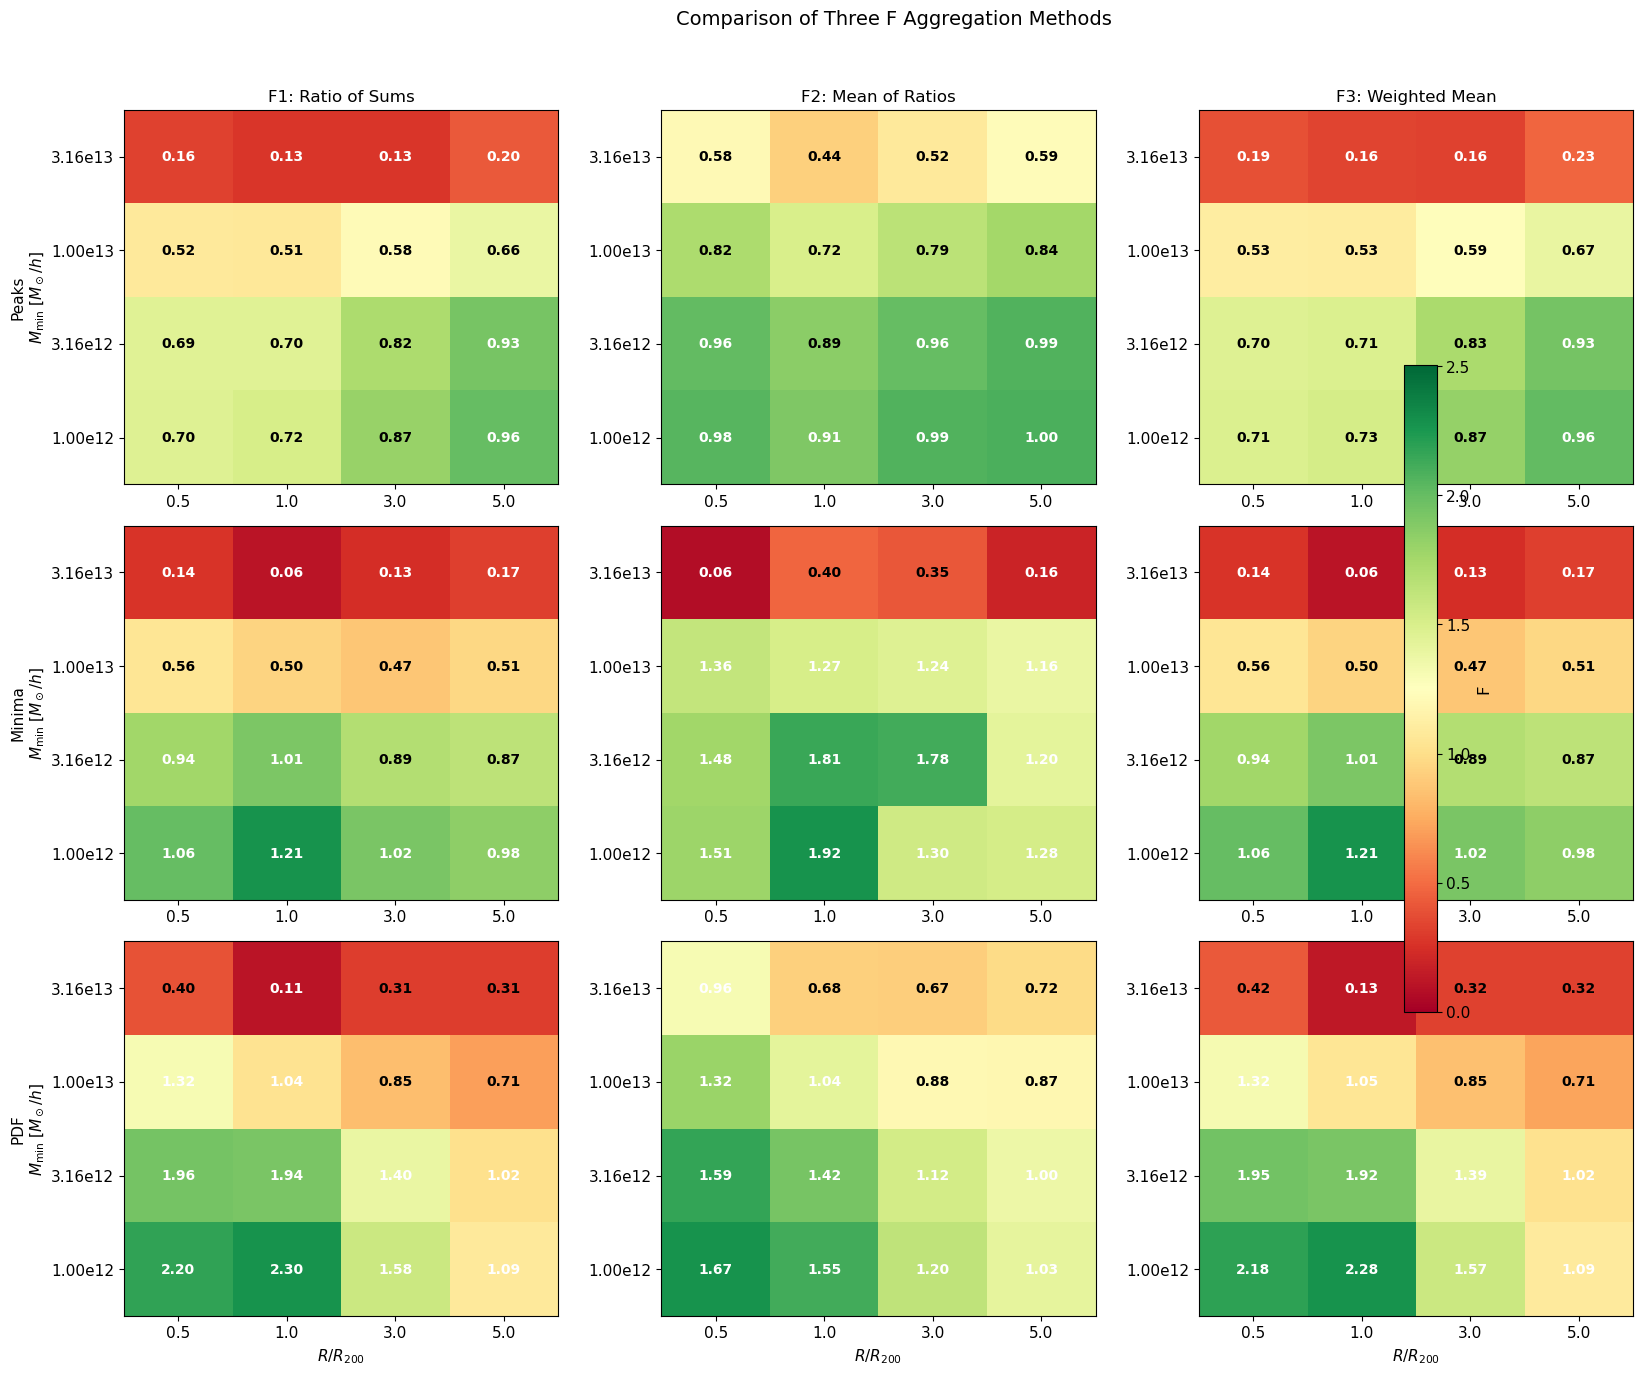


Summary: Difference between methods (F2 - F1) and (F3 - F1)
Using 1% relative threshold: |ΔN/N_D| > 0.01

PEAKS:
Model                                               F1       F2       F3      F2-F1      F3-F1
-----------------------------------------------------------------------------------------------
M > 1.00e12, R < 5.0                             0.961    1.003    0.963     +0.042     +0.002
M > 3.16e12, R < 5.0                             0.927    0.991    0.931     +0.064     +0.003
M > 1.00e13, R < 5.0                             0.661    0.839    0.670     +0.178     +0.009
M > 3.16e13, R < 5.0                             0.205    0.589    0.226     +0.384     +0.021

MINIMA:
Model                                               F1       F2       F3      F2-F1      F3-F1
-----------------------------------------------------------------------------------------------
M > 1.00e12, R < 5.0                             0.975    1.284    0.975     +0.309     +0.000
M > 3.16e12, R < 5.0

In [61]:
# =============================================================================
# Compare all three methods across all models - Heatmap visualization
# =============================================================================

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

method_names = ['F1: Ratio of Sums', 'F2: Mean of Ratios', 'F3: Weighted Mean']
stat_configs = [
    ('Peaks', N_D_peaks, N_H_peaks, peak_counts_sn),
    ('Minima', N_D_minima, N_H_minima, minima_counts_sn),
    ('PDF', N_D_pdf, N_H_pdf, pdf_counts_sn)
]

for stat_idx, (stat_name, N_D_arr, N_H_arr, counts_dict) in enumerate(stat_configs):
    # Compute F for all models using all three methods
    F1_grid = np.zeros((len(mass_thresholds_cum), len(radii_cum)))
    F2_grid = np.zeros((len(mass_thresholds_cum), len(radii_cum)))
    F3_grid = np.zeros((len(mass_thresholds_cum), len(radii_cum)))
    
    for m_idx, mass_thr in enumerate(mass_thresholds_cum):
        for r_idx, r in enumerate(radii_cum):
            model = f'hydro_replace_Ml_{mass_thr}_Mu_inf_R_{r}'
            N_R_arr = get_total_counts(counts_dict, model)
            F1, F2, F3 = compute_three_F_methods(N_R_arr, N_D_arr, N_H_arr)
            F1_grid[m_idx, r_idx] = F1
            F2_grid[m_idx, r_idx] = F2
            F3_grid[m_idx, r_idx] = F3
    
    # Plot heatmaps
    for method_idx, (F_grid, method_name) in enumerate([(F1_grid, method_names[0]), 
                                                         (F2_grid, method_names[1]), 
                                                         (F3_grid, method_names[2])]):
        ax = axes[stat_idx, method_idx]
        
        # Determine color scale based on data range
        vmin, vmax = 0, max(1.2, np.nanmax(F_grid) * 1.1)
        
        im = ax.imshow(F_grid, cmap='RdYlGn', vmin=vmin, vmax=vmax, aspect='auto', origin='lower')
        
        for i in range(len(mass_thresholds_cum)):
            for j in range(len(radii_cum)):
                val = F_grid[i, j]
                text_color = 'white' if val < 0.3 or val > 0.9 else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                        color=text_color, fontsize=10, fontweight='bold')
        
        ax.set_xticks(range(len(radii_cum)))
        ax.set_xticklabels([f'{r}' for r in radii_cum])
        ax.set_yticks(range(len(mass_thresholds_cum)))
        ax.set_yticklabels([f'{m}' for m in mass_thresholds_cum])
        
        if method_idx == 0:
            ax.set_ylabel(f'{stat_name}\n' + r'$M_{\min}$ [$M_\odot/h$]', fontsize=11)
        if stat_idx == 2:
            ax.set_xlabel(r'$R/R_{200}$', fontsize=11)
        if stat_idx == 0:
            ax.set_title(method_name, fontsize=12)

fig.colorbar(im, ax=axes, label='F', shrink=0.6, pad=0.02)
plt.suptitle('Comparison of Three F Aggregation Methods', fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 0.92, 0.96])
plt.show()

# =============================================================================
# Print summary table
# =============================================================================
print("\n" + "=" * 110)
print("Summary: Difference between methods (F2 - F1) and (F3 - F1)")
print("Using 1% relative threshold: |ΔN/N_D| > 0.01")
print("=" * 110)

for stat_name, N_D_arr, N_H_arr, counts_dict in stat_configs:
    print(f"\n{stat_name.upper()}:")
    print(f"{'Model':<45} {'F1':>8} {'F2':>8} {'F3':>8} {'F2-F1':>10} {'F3-F1':>10}")
    print("-" * 95)
    
    for m_idx, mass_thr in enumerate(mass_thresholds_cum):
        model = f'hydro_replace_Ml_{mass_thr}_Mu_inf_R_5.0'  # R=5.0 only
        N_R_arr = get_total_counts(counts_dict, model)
        F1, F2, F3 = compute_three_F_methods(N_R_arr, N_D_arr, N_H_arr)
        print(f"M > {mass_thr}, R < 5.0{'':<25} {F1:>8.3f} {F2:>8.3f} {F3:>8.3f} {F2-F1:>+10.3f} {F3-F1:>+10.3f}")

print("\n" + "=" * 110)
print("Key observations:")
print("- F1 and F3 are identical when all ΔN have the same sign")
print("- F2 (mean of ratios) can differ significantly if bins have different ΔN magnitudes")
print("- For PDF, methods diverge because ΔN changes sign across bins")
print("=" * 110)

In [62]:
# =============================================================================
# Diagnostic: Check which bins pass the threshold and their F values
# =============================================================================

print("Diagnostic: Per-bin F values and significance threshold")
print("=" * 100)

# Test case: Minima with M > 10^12, R < 0.5 (one that gave F2 = -0.79)
model_diag = 'hydro_replace_Ml_1.00e12_Mu_inf_R_0.5'
N_R_diag = get_total_counts(minima_counts_sn, model_diag)

Delta_N_diag = N_H_minima - N_D_minima
N_R_minus_D_diag = N_R_diag - N_D_minima

# Per-bin F
with np.errstate(divide='ignore', invalid='ignore'):
    F_per_bin_diag = N_R_minus_D_diag / Delta_N_diag

min_counts_test = 100  # Current threshold

print(f"\nMINIMA for {model_diag}")
print(f"Threshold: |ΔN| > {min_counts_test}")
print(f"\n{'S/N':<8} {'N_D':>10} {'N_H':>10} {'N_R':>10} {'ΔN':>10} {'N_R-N_D':>10} {'F':>10} {'Pass?':>8}")
print("-" * 90)

n_pass = 0
F_values_passing = []
for i, sn in enumerate(MINIMA_CENTERS):
    dn = Delta_N_diag[i]
    passes = np.abs(dn) > min_counts_test
    F_i = F_per_bin_diag[i]
    
    status = "YES" if passes else "no"
    if passes:
        n_pass += 1
        F_values_passing.append(F_i)
    
    # Highlight problematic bins
    if passes and (F_i < -0.5 or F_i > 2.0):
        status += " ⚠️"
    
    print(f"{sn:<8.1f} {N_D_minima[i]:>10.0f} {N_H_minima[i]:>10.0f} {N_R_diag[i]:>10.0f} "
          f"{dn:>+10.0f} {N_R_minus_D_diag[i]:>+10.0f} {F_i:>10.2f} {status:>8}")

print(f"\nBins passing threshold: {n_pass} / {len(MINIMA_CENTERS)}")
print(f"F values of passing bins: {[f'{f:.2f}' for f in F_values_passing]}")
print(f"Mean of passing F values (F2): {np.mean(F_values_passing):.4f}")

# The issue: some bins have small |ΔN| but still pass, and have extreme F
# Let's see what happens with a stricter threshold
print("\n" + "=" * 100)
print("Effect of increasing threshold on F2 (Mean of Ratios)")
print("=" * 100)

for min_thresh in [100, 500, 1000, 2000, 5000]:
    passes = np.abs(Delta_N_diag) > min_thresh
    F_valid = F_per_bin_diag[passes & np.isfinite(F_per_bin_diag)]
    n_bins = len(F_valid)
    F2_test = np.mean(F_valid) if n_bins > 0 else np.nan
    print(f"  min_counts = {min_thresh:>5}: {n_bins:>2} bins pass, F2 = {F2_test:.4f}")

Diagnostic: Per-bin F values and significance threshold

MINIMA for hydro_replace_Ml_1.00e12_Mu_inf_R_0.5
Threshold: |ΔN| > 100

S/N             N_D        N_H        N_R         ΔN    N_R-N_D          F    Pass?
------------------------------------------------------------------------------------------
-4.5              0          0          0         +0         +0        nan       no
-3.5              0          0          0         +0         +0        nan       no
-2.5           2252       2047       1779       -205       -473       2.31   YES ⚠️
-1.5          88651      85519      85617      -3132      -3034       0.97      YES
-0.5         100339     100007     102213       -332      +1874      -5.64   YES ⚠️
0.5           16594      16531      16415        -63       -179       2.84       no
1.5            1305       1263       1238        -42        -67       1.60       no
2.5              81         79         77         -2         -4       2.00       no
3.5               8     

In [63]:
# =============================================================================
# Diagnostic: Show which bins pass the 1% relative threshold
# =============================================================================

print("Bin Selection: Include bins where |ΔN/N_D| > 1%")
print("=" * 100)

model_diag = 'hydro_replace_Ml_1.00e12_Mu_inf_R_0.5'

for stat_name, N_D_arr, N_H_arr, counts_dict, centers in [
    ('PEAKS', N_D_peaks, N_H_peaks, peak_counts_sn, PEAK_CENTERS),
    ('MINIMA', N_D_minima, N_H_minima, minima_counts_sn, MINIMA_CENTERS),
    ('PDF', N_D_pdf, N_H_pdf, pdf_counts_sn, PDF_CENTERS)
]:
    print(f"\n{stat_name}:")
    print(f"{'S/N':<8} {'N_D':>12} {'N_H':>12} {'ΔN':>10} {'|ΔN/N_D|%':>12} {'Pass?':>8}")
    print("-" * 70)
    
    Delta_N = N_H_arr - N_D_arr
    rel_effect = np.abs(Delta_N) / (N_D_arr + 1)
    passes = rel_effect > 0.01
    
    for i, sn in enumerate(centers):
        status = 'YES' if passes[i] else 'no'
        print(f"{sn:<8.1f} {N_D_arr[i]:>12.0f} {N_H_arr[i]:>12.0f} {Delta_N[i]:>+10.0f} "
              f"{100*rel_effect[i]:>12.2f} {status:>8}")
    
    n_pass = np.sum(passes)
    n_fail = len(passes) - n_pass
    print(f"\n  → {n_pass} bins pass threshold, {n_fail} excluded")

print("\n" + "=" * 100)
print("This 1% relative threshold is now applied consistently to all F computations")
print("=" * 100)

Bin Selection: Include bins where |ΔN/N_D| > 1%

PEAKS:
S/N               N_D          N_H         ΔN    |ΔN/N_D|%    Pass?
----------------------------------------------------------------------
-4.5                0            0         +0         0.00       no
-3.5                0            0         +0         0.00       no
-2.5                2            2         +0         0.00       no
-1.5             3241         3084       -157         4.84      YES
-0.5            45019        44464       -555         1.23      YES
0.5             81886        80875      -1011         1.23      YES
1.5             55045        53983      -1062         1.93      YES
2.5             24532        23900       -632         2.58      YES
3.5             10228         9952       -276         2.70      YES
4.5              4082         3989        -93         2.28      YES
5.5              1980         1941        -39         1.97      YES
6.5               936          931         -5         0.5